# Deep Koopman MPC Portfolio Optimizer — Risk-Based Architecture
**A Decoupled Radar-Agent System for the BSE SENSEX-30**

---

## Theoretical Foundation

This notebook implements a strictly decoupled two-module pipeline that separates the *observer* from the *decision-maker*:

### Why Decoupled?

The previous architecture coupled the portfolio weights **uₜ** into the neural network via a control matrix **B**. This is problematic:
- We are a **price-taker** — our trades do not meaningfully move the market state.
- Feeding **uₜ** into the network forces it to learn spurious correlations between our allocations and market dynamics.
- The **B** matrix can never be properly identified because the training signal uses a fixed equal-weight portfolio.

### The Two-Module Pipeline

**System 1 — Koopman Radar (PyTorch):** An autonomous observer. It ingests chaotic market indicators and forecasts a 7-day trajectory of the **Covariance Matrix (Σ)** — deliberately avoiding noisy return prediction.

**System 2 — Risk-Based MPC (CVXPY):** A control agent. It takes the forecasted Σ trajectory and solves for optimal weights that minimise dynamic variance and transaction friction.

### System 1: The Deep Koopman Radar
Four learnable objects — the network is entirely **blind to our trading actions**:
- **Encoder ϕ**: Non-linear NN. Compresses observable market state **xₜ** → latent state **zₜ**.
- **Transition Matrix K**: Linear layer (`nn.Linear`, no bias). Steps the market forward: **zₜ₊₁ = K·zₜ**.
- **Risk Readout C**: Linear layer. Maps the latent state to the Covariance matrix: **Σₜ = C(zₜ)**.
- **Decoder ψ**: Non-linear NN. Maps **zₜ → x̂ₜ** to ensure latent space validity.

### Loss Function (Physics Constraints)
$$L_{Total} = L_{recon} + \alpha L_{linear} + \beta L_{risk} + \gamma L_{stability}$$
- $L_{recon}$: $\|\psi(\phi(x_t)) - x_t\|^2$ — autoencoder fidelity.
- $L_{linear}$: $\|Kz_t - \phi(x_{t+1})\|^2$ — forces latent space to be mathematically linear.
- $L_{risk}$: $\|C(z_t) - \Sigma_t^{actual}\|^2_F$ — supervises the risk readout.
- $L_{stability}$: Spectral radius penalty $\text{ReLU}(|\lambda(K)| - 0.99)^2$ — guarantees 7-day forecast won't explode.

### System 2: Risk-Based MPC (7-Day Horizon)
$$J = \min_{u} \sum_{k=1}^{7} \left( u_{t+k}^T \Sigma_{t+k} u_{t+k} + \lambda \|u_{t+k} - u_{t+k-1}\|_1 \right)$$
Subject to: $\sum u_{t+k} = 1$, $u_{t+k} \ge 0$, $u_{t+k} \le w_{max}$.

---
**Universe**: BSE SENSEX-30 | **Period**: 2014–2024 | **Benchmark**: BSE Sensex (^BSESN)

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install yfinance cvxpy torch --quiet

In [2]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import cvxpy as cp
import yfinance as yf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {device}')
print(f'PyTorch     : {torch.__version__}')
print(f'CVXPY       : {cp.__version__}')

Device      : cuda
PyTorch     : 2.11.0+cu130
CVXPY       : 1.8.2


In [3]:
# ── Global Seed for Reproducibility ───────────────────────────────────────────
import os
import random

def seed_everything(seed: int = 42):
    """Locks all random-dependent modules to ensure reproducible runs."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups
        # Force cuDNN to use deterministic algorithms
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(67)
print("Global seed set. cuDNN determinism enabled.")

Global seed set. cuDNN determinism enabled.


In [4]:
# ── Create output directories ─────────────────────────────────────────────────
import os
for d in ['./plots', './models/checkpoints', './models/matrices', './data', './results']:
    os.makedirs(d, exist_ok=True)
print('Output directories ready.')

Output directories ready.


## Configuration
All hyperparameters are centralised here. Change only this cell to experiment.

In [5]:
# ── Datasets ──────────────────────────────────────────────────────────────────
SENSEX_30 = [
    'RELIANCE.BO',  'TCS.BO',       'HDFCBANK.BO',  'INFY.BO',      'ICICIBANK.BO',
    'HINDUNILVR.BO','ITC.BO',       'SBIN.BO',      'BHARTIARTL.BO','KOTAKBANK.BO',
    'LT.BO',        'AXISBANK.BO',  'ASIANPAINT.BO','MARUTI.BO',    'SUNPHARMA.BO',
    'TITAN.BO',     'BAJFINANCE.BO','WIPRO.BO',     'ONGC.BO',      'NTPC.BO',
    'POWERGRID.BO', 'ULTRACEMCO.BO','NESTLEIND.BO', 'BAJAJFINSV.BO','TATAMOTORS.NS',
    'HCLTECH.BO',   'TATASTEEL.BO', 'JSWSTEEL.BO',  'M&M.BO',       'ADANIENT.BO',
]
SENSEX_BENCHMARK = '^BSESN'

NIFTY_50 = [
    'RELIANCE.NS','TCS.NS','HDFCBANK.NS','INFY.NS','ICICIBANK.NS',
    'HINDUNILVR.NS','ITC.NS','SBIN.NS','BHARTIARTL.NS','KOTAKBANK.NS',
    'LT.NS','AXISBANK.NS','ASIANPAINT.NS','MARUTI.NS','SUNPHARMA.NS',
    'TITAN.NS','BAJFINANCE.NS','WIPRO.NS','ONGC.NS','NTPC.NS',
    'POWERGRID.NS','ULTRACEMCO.NS','NESTLEIND.NS','BAJAJFINSV.NS','TATAMOTORS.NS',
    'HCLTECH.NS','TATASTEEL.NS','JSWSTEEL.NS','M&M.NS','ADANIENT.NS',

    'ADANIPORTS.NS','APOLLOHOSP.NS','BAJAJ-AUTO.NS','BPCL.NS','BRITANNIA.NS',
    'CIPLA.NS','COALINDIA.NS','DIVISLAB.NS','DRREDDY.NS','EICHERMOT.NS',
    'GRASIM.NS','HDFCLIFE.NS','HEROMOTOCO.NS','HINDALCO.NS','INDUSINDBK.NS',
    'JSWSTEEL.NS','LTIM.NS','SBILIFE.NS','SHRIRAMFIN.NS','TECHM.NS',
    'UPL.NS'
]
NIFTY_BENCHMARK = '^NSEI'

BANKING = [
    'HDFCBANK.NS','ICICIBANK.NS','SBIN.NS','KOTAKBANK.NS',
    'AXISBANK.NS','INDUSINDBK.NS','BANKBARODA.NS'
]
BANKING_BENCHMARK = '^NSEBANK'

IT = [
    'TCS.NS','INFY.NS','HCLTECH.NS','WIPRO.NS','TECHM.NS','LTIM.NS'
]
IT_BENCHMARK = '^CNXIT'

METALS_ENERGY = [
    'TATASTEEL.NS','JSWSTEEL.NS','HINDALCO.NS','ONGC.NS',
    'COALINDIA.NS','BPCL.NS','IOC.NS'
]
METALS_ENERGY_BENCHMARK = '^CNXMETAL'

SP500 = [
    'MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A',
    'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL',
    'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK',
    'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'AAPL', 'AMAT',
    'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP',
    'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B',
    'BBY', 'TECH', 'BIO', 'BIIB', 'BLK', 'BX', 'BA', 'BKNG', 'BSX', 'BMY',
    'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'CDNS', 'CZR', 'CPT', 'CPB',
    'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW',
    'COR', 'CNC', 'CNP', 'CF', 'CHRW', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG',
    'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME',
    'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CAG', 'COP', 'ED', 'STZ',
    'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD',
    'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'DAY', 'DECK', 'DE',
    'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DFS', 'DG', 'DLTR', 'D', 'DPZ',
    'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'EMN', 'ETN', 'EBAY', 'ECL',
    'EIX', 'EW', 'EA', 'ELV', 'LLY', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM',
    'EQT', 'EFX', 'EQIX', 'EQR', 'ESS', 'EL', 'ETSY', 'EG', 'EVRG', 'ES',
    'EXC', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST', 'FRT',
    'FDX', 'FIS', 'FITB', 'FSLR', 'FE', 'FI', 'FMC', 'F', 'FTNT', 'FTV',
    'FOXA', 'FOX', 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEV', 'GEN',
    'GNRC', 'GD', 'GIS', 'GM', 'GPC', 'GILD', 'GPN', 'GL', 'GDDY', 'GS',
    'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HES', 'HPE', 'HLT',
    'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN',
    'HII', 'IBM', 'IEX', 'IDXX', 'ITW', 'INCY', 'IR', 'PODD', 'INTC', 'ICE',
    'IFF', 'IP', 'IPG', 'INTU', 'ISRG', 'IVZ', 'INVH', 'IQV', 'IRM', 'JBHT',
    'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'JNPR', 'K', 'KVUE', 'KDP',
    'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX',
    'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LIN', 'LYV', 'LKQ', 'LMT',
    'L', 'LOW', 'LULU', 'LYB', 'MTB', 'MRO', 'MPC', 'MKTX', 'MAR', 'MMC',
    'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META',
    'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH',
    'TAP', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ',
    'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC',
    'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY',
    'ODFL', 'OMC', 'ON', 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PH',
    'PAYX', 'PAYC', 'PYPL', 'PNR', 'PEP', 'PFE', 'PCG', 'PM', 'PSX', 'PNW',
    'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG',
    'PTC', 'PSA', 'PHM', 'QRVO', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX',
    'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'ROK', 'ROL', 'ROP',
    'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW',
    'SPG', 'SWKS', 'SJM', 'SW', 'SNA', 'SOLV', 'SO', 'LUV', 'SWK', 'SBUX',
    'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW',
    'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TFX', 'TER', 'TSLA', 'TXN',
    'TPL', 'TXT', 'TMO', 'TJX', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC',
    'TYL', 'TSN', 'USB', 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI',
    'UNH', 'UHS', 'VLO', 'VTR', 'VLTO', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VTRS',
    'VICI', 'V', 'VST', 'VMC', 'WRB', 'GWW', 'WAB', 'WBA', 'WMT', 'DIS', 'WBD',
    'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WMB', 'WTW', 'WYNN',
    'XEL', 'XYZ', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS',
]
SP500_BENCHMARK = '^GSPC'

In [6]:

# ── Date ranges ───────────────────────────────────────────────────────────────
START_DATE  = '2014-01-01'
END_DATE    = '2024-12-31'
TRAIN_END   = '2021-12-31'
VAL_END     = '2022-12-31'
# Test = 2023-01-01 → 2024-12-31

# ── Feature / model geometry ──────────────────────────────────────────────────
WINDOW          = 10    # W: trading-day lookback window per sample
N_FEATURES      = 7     # F: per-stock features (see engineering cell)
STOCK_EMBED_DIM = 64    # per-stock latent dimension (Stage-1 encoder output)
LATENT_DIM      = 64    # portfolio-level latent dim |z_t|
DROPOUT         = 0.10

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
N_EPOCHS   = 80
LR         = 3e-4
PATIENCE   = 15

# Loss weights — blueprint: L_recon + α*L_linear + β*L_risk + γ*L_stability
#   L_recon     : autoencoder reconstruction fidelity
#   L_linear    : Koopman linearisation  ← most important, keep highest
#   L_risk      : covariance (Σ) prediction quality
#   L_stability : spectral radius penalty on K
LAMBDA_RECON     = 1.0
LAMBDA_LINEAR    = 4.0   # α
LAMBDA_RISK      = 2.0   # β
LAMBDA_STABILITY = 0.5   # γ

# ── Σ regularisation (PD guarantee in C readout) ──────────────────────────────
# A small ridge added to the symmetrised C output matrix during both training
# (decode_sigma) and inference (_forecast_sigmas) to guarantee positive-definiteness.
SIGMA_REG = 1e-4

# ── MPC (Phase 2) ─────────────────────────────────────────────────────────────
H          = 7       # planning horizon (days)
LAMBDA_TC  = 0.001   # L1 transaction friction coefficient (≈ 10 bps per unit turnover)
MAX_WEIGHT = 0.20    # max single-stock weight (long-only, diversification cap)

# ── Log Return feature index ──────────────────────────────────────────────────
LOGRET_IDX = 0   # feature 0 is log_return (see engineering cell)

In [7]:
# Control data and benchmarks from here (Nifty, Sensex, etc)
DATA_BENCHMARKS = [SENSEX_30, SENSEX_BENCHMARK]

In [8]:
print('Configuration loaded.')
print(f'  Universe    : {len(DATA_BENCHMARKS[0])} tickers')
print(f'  Latent dim  : {LATENT_DIM}')
print(f'  MPC horizon : H = {H} days')
print(f'  Loss weights: recon={LAMBDA_RECON}, linear={LAMBDA_LINEAR}, risk={LAMBDA_RISK}, stability={LAMBDA_STABILITY}')

Configuration loaded.
  Universe    : 30 tickers
  Latent dim  : 64
  MPC horizon : H = 7 days
  Loss weights: recon=1.0, linear=4.0, risk=2.0, stability=0.5


## Phase 1 — Step 1: Data Pipeline
Download 10 years of OHLCV data, enforce data-quality thresholds, forward-fill small gaps.

In [9]:
def download_data(tickers, start, end, missing_thresh=0.05):
    """Download OHLCV; drop tickers with > missing_thresh fraction of NaN closes."""
    print(f'Downloading {len(tickers)} tickers  [{start} → {end}] ...')
    raw  = yf.download(tickers, start=start, end=end,
                       auto_adjust=True, progress=True, threads=False)
    ohlcv = raw[['Open', 'High', 'Low', 'Close', 'Volume']]

    close       = ohlcv['Close']
    missing_pct = close.isna().mean()
    bad         = missing_pct[missing_pct > missing_thresh].index.tolist()
    if bad:
        print(f'  Dropping (>{missing_thresh*100:.0f}% missing): {bad}')
        ohlcv = ohlcv.drop(columns=bad, level=1)

    ohlcv = ohlcv.ffill().bfill()
    n_stocks = ohlcv['Close'].shape[1]
    print(f'  Final shape : {ohlcv.shape}  |  stocks retained : {n_stocks}')
    return ohlcv


In [10]:
ohlcv_data    = download_data(DATA_BENCHMARKS[0], START_DATE, END_DATE)
benchmark_raw = yf.download(DATA_BENCHMARKS[1], start=START_DATE, end=END_DATE,
                            auto_adjust=True, progress=False)
TICKERS = ohlcv_data['Close'].columns.tolist()
N_STOCKS = len(TICKERS)
print(f'\nN_STOCKS = {N_STOCKS}')
print(f'Tickers  : {TICKERS}')

[**********************80%*************          ]  24 of 30 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  30 of 30 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


  Dropping (>5% missing): ['TATAMOTORS.NS']
  Final shape : (2708, 145)  |  stocks retained : 29

N_STOCKS = 29
Tickers  : ['ADANIENT.BO', 'ASIANPAINT.BO', 'AXISBANK.BO', 'BAJAJFINSV.BO', 'BAJFINANCE.BO', 'BHARTIARTL.BO', 'HCLTECH.BO', 'HDFCBANK.BO', 'HINDUNILVR.BO', 'ICICIBANK.BO', 'INFY.BO', 'ITC.BO', 'JSWSTEEL.BO', 'KOTAKBANK.BO', 'LT.BO', 'M&M.BO', 'MARUTI.BO', 'NESTLEIND.BO', 'NTPC.BO', 'ONGC.BO', 'POWERGRID.BO', 'RELIANCE.BO', 'SBIN.BO', 'SUNPHARMA.BO', 'TATASTEEL.BO', 'TCS.BO', 'TITAN.BO', 'ULTRACEMCO.BO', 'WIPRO.BO']


## Phase 1 — Step 2: Feature Engineering (State Vector **xₜ**)

For each stock, we construct a 7-dimensional daily feature vector:

| # | Feature | Description |
|---|---------|-------------|
| 0 | `log_return` | Daily log return — stationary price proxy |
| 1 | `vol_20` | 20-day rolling std of log returns — realised volatility |
| 2 | `momentum_10` | 10-day cumulative log return — medium-term trend |
| 3 | `rsi_14` | 14-day RSI normalised to [−0.5, +0.5] — mean-reversion signal |
| 4 | `macd_signal` | MACD histogram / price — trend strength |
| 5 | `hl_range` | (High−Low)/Close — intra-day volatility proxy |
| 6 | `volume_z` | 20-day z-score of log volume — liquidity signal |

**Design rationale**: The encoder ϕ ingests **xₜ** and produces **zₜ**. Portfolio weights **uₜ** never touch these raw features — the network is entirely blind to our trading actions.

In [11]:
FEATURE_NAMES = ['log_return', 'vol_20', 'momentum_10',
                 'rsi_14', 'macd_signal', 'hl_range', 'volume_z']

In [12]:
def _rsi(series, period=14):
    d     = series.diff()
    gain  = d.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss  = (-d.clip(upper=0)).ewm(alpha=1/period, adjust=False).mean()
    rs    = gain / (loss + 1e-9)
    return rs / (1 + rs) - 0.5   # normalise to [-0.5, 0.5]


def compute_features(ohlcv):
    """Returns a 3-D numpy array of shape (T, N_stocks, F)."""
    tickers = ohlcv['Close'].columns.tolist()
    frames  = []

    for tk in tickers:
        c = ohlcv['Close'][tk]
        h = ohlcv['High'][tk]
        l = ohlcv['Low'][tk]
        v = ohlcv['Volume'][tk]

        log_ret  = np.log(c / c.shift(1))
        vol_20   = log_ret.rolling(20).std()
        mom_10   = log_ret.rolling(10).sum()
        rsi      = _rsi(c, 14)
        ema12    = c.ewm(span=12, adjust=False).mean()
        ema26    = c.ewm(span=26, adjust=False).mean()
        macd_h   = (ema12 - ema26) / (c + 1e-9)
        hl_range = (h - l) / (c + 1e-9)
        log_vol  = np.log(v + 1)
        vol_z    = (log_vol - log_vol.rolling(20).mean()) / (log_vol.rolling(20).std() + 1e-9)

        frames.append(pd.DataFrame({
            'log_return'  : log_ret,
            'vol_20'      : vol_20,
            'momentum_10' : mom_10,
            'rsi_14'      : rsi,
            'macd_signal' : macd_h,
            'hl_range'    : hl_range,
            'volume_z'    : vol_z,
        }))

    common_idx = frames[0].index
    for f in frames[1:]:
        common_idx = common_idx.intersection(f.index)

    aligned  = [f.loc[common_idx] for f in frames]
    data_3d  = np.stack([f.values for f in aligned], axis=1)  # (T, N, F)

    first_valid = np.where(~np.isnan(data_3d).any(axis=(1, 2)))[0][0]
    return data_3d[first_valid:], common_idx[first_valid:]


In [13]:
print('Engineering features...')
data_3d, date_index = compute_features(ohlcv_data)
print(f'3-D tensor (T, N_stocks, F) : {data_3d.shape}')
print(f'Date range                  : {date_index[0].date()} → {date_index[-1].date()}')

Engineering features...
3-D tensor (T, N_stocks, F) : (2688, 29, 7)
Date range                  : 2014-01-29 → 2024-12-30


## Phase 1 — Step 3: Covariance Estimator, Split, Normalise, Dataset

The `estimate_sigma` function is defined here (early) because it is needed in three places:
1. **Dataset construction** — computing per-sample Σ targets for the risk loss.
2. **Matrix diagnostics** — training-period Σ for visualisation.
3. **Weight attribution** — re-running MPC on the first 200 test days.

**Dataset design**: Each sample yields `(x_t, x_t1, Sigma_t)` tuples:
- `x_t`  — current window `(N, W, F)` → input to encoder ϕ
- `x_t1` — next window `(N, W, F)` → target for Koopman linearisation loss
- `Sigma_t` — `(N, N)` actual covariance of the window that produced `x_t`, computed from raw (un-normalised) log returns. This is the label for the **C** risk-readout matrix.

**Key architectural invariant**: No portfolio weights **u** ever enter the dataset. The Koopman radar is fully autonomous.

In [14]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
train_mask = date_index <= TRAIN_END
val_mask   = (date_index > TRAIN_END) & (date_index <= VAL_END)
test_mask  = date_index > VAL_END

data_train = data_3d[train_mask]
data_val   = data_3d[val_mask]
data_test  = data_3d[test_mask]

for name, d, m in [('Train', data_train, train_mask),
                   ('Val',   data_val,   val_mask),
                   ('Test',  data_test,  test_mask)]:
    print(f'{name:5s}: {d.shape[0]} days  '
          f'({date_index[m][0].date()} → {date_index[m][-1].date()})')

# ── Normalise (train stats only) ──────────────────────────────────────────────
train_mean = np.nanmean(data_train, axis=(0, 1))    # (F,)
train_std  = np.nanstd(data_train,  axis=(0, 1))    # (F,)
train_std  = np.where(train_std < 1e-8, 1e-8, train_std)

def normalise(x): return (x - train_mean) / train_std

data_train_n = normalise(data_train)
data_val_n   = normalise(data_val)
data_test_n  = normalise(data_test)

# ── Save artefacts for later phases ──────────────────────────────────────────
np.save('./data/train_mean.npy',        train_mean)
np.save('./data/train_std.npy',         train_std)
np.save('./data/data_test_n.npy',       data_test_n)
np.save('./data/date_index_test.npy',   date_index[test_mask].astype(str))
np.save('./data/tickers_retained.npy',  np.array(TICKERS))

print(f'\nTrain mean ≈ 0: {data_train_n.mean(axis=(0,1)).round(3)}')
print(f'Train std  ≈ 1: {data_train_n.std( axis=(0,1)).round(3)}')

Train: 1950 days  (2014-01-29 → 2021-12-31)
Val  : 248 days  (2022-01-03 → 2022-12-30)
Test : 490 days  (2023-01-02 → 2024-12-30)

Train mean ≈ 0: [-0.  0. -0.  0. -0. -0. -0.]
Train std  ≈ 1: [1. 1. 1. 1. 1. 1. 1.]


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# COVARIANCE ESTIMATION (defined early — used by Dataset, diagnostics, backtest)
# ─────────────────────────────────────────────────────────────────────────────

def estimate_sigma(log_returns: np.ndarray, shrinkage: float = 0.1) -> np.ndarray:
    """
    Compute shrunk sample covariance matrix.
    Σ_shrunk = (1 - α)·Σ_sample + α·(trace(Σ)/N)·I

    Shrinkage towards scaled identity improves condition number, preventing
    the MPC from concentrating in poorly-estimated low-variance directions.
    With small windows (W=10) and large N, shrinkage is essential for PD output.

    Args:
        log_returns : (T, N) matrix of daily log returns
        shrinkage   : α ∈ [0, 1]  (0 = sample only, 1 = identity only)
    Returns:
        Σ : (N, N) positive-definite covariance matrix
    """
    T, N   = log_returns.shape
    mu     = log_returns.mean(axis=0)
    demeaned = log_returns - mu
    Sigma_s  = (demeaned.T @ demeaned) / max(T - 1, 1)    # sample covariance
    target   = (np.trace(Sigma_s) / N) * np.eye(N)        # scaled identity target
    return (1 - shrinkage) * Sigma_s + shrinkage * target


print('estimate_sigma defined.')

estimate_sigma defined.


In [16]:
class KoopmanDataset(Dataset):
    """
    Sliding-window dataset that yields three quantities needed to train
    the decoupled Koopman Radar (ϕ, K, C, ψ).

    For a window ending at time idx+W-1, the sample is:
      x_t     : (N, W, F)  — observable state at t   → train encoder ϕ
      x_t1    : (N, W, F)  — observable state at t+1 → train K (Koopman target)
      Sigma_t : (N, N)     — covariance of the window that produced x_t
                             → supervise risk-readout C

    CRITICAL — No portfolio weights u ever appear in this dataset.
    The network is entirely blind to our trading decisions.
    The Sigma targets are pre-computed from raw (un-normalised) log returns
    so that the scale of the covariance matrix is physically meaningful.
    """
    def __init__(self, data_norm: np.ndarray, raw_log_returns: np.ndarray,
                 window: int, cov_shrinkage: float = 0.2):
        assert data_norm.ndim == 3, 'Expected (T, N, F)'
        self.data = torch.tensor(data_norm, dtype=torch.float32)   # (T, N, F)
        self.W    = window
        self.T, self.N, self.F = data_norm.shape
        # valid pairs: x_t ends at idx+W-1, x_t1 ends at idx+W → idx+W+1 ≤ T
        self.n_samples = self.T - self.W - 1

        # Pre-compute Σ targets for every sample (raw, un-normalised log returns)
        # Σ_t = shrunk_cov(raw_log_returns[idx : idx+W])
        # C learns: z_t (latent state of window) → contemporaneous Σ_t
        # Inference: Σ_{t+k} = C(K^k z_t) — K propagates z, C reads out Σ
        print(f'  Pre-computing {self.n_samples} covariance targets...')
        sigmas = []
        for idx in range(self.n_samples):
            ret_slice = raw_log_returns[idx : idx + self.W]   # (W, N)
            sigmas.append(estimate_sigma(ret_slice, shrinkage=cov_shrinkage))
        self.sigmas = torch.tensor(
            np.stack(sigmas, axis=0), dtype=torch.float32
        )  # (n_samples, N, N)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Sliding windows — (W, N, F) → permute → (N, W, F)
        x_t  = self.data[idx     : idx + self.W    ].permute(1, 0, 2)  # (N, W, F)
        x_t1 = self.data[idx + 1 : idx + self.W + 1].permute(1, 0, 2) # (N, W, F)
        Sigma_t = self.sigmas[idx]                                       # (N, N)
        return x_t, x_t1, Sigma_t


In [17]:
# Raw (un-normalised) log returns for covariance target computation
raw_logret_train = data_train[:, :, LOGRET_IDX]   # (T_train, N)
raw_logret_val   = data_val[:,   :, LOGRET_IDX]   # (T_val,   N)
raw_logret_test  = data_test[:,  :, LOGRET_IDX]   # (T_test,  N)

print('Building datasets...')
train_ds = KoopmanDataset(data_train_n, raw_logret_train, WINDOW)
val_ds   = KoopmanDataset(data_val_n,   raw_logret_val,   WINDOW)
test_ds  = KoopmanDataset(data_test_n,  raw_logret_test,  WINDOW)

kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=(device.type == 'cuda'))
train_loader = DataLoader(train_ds, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Test  samples : {len(test_ds)}')

x_t, x_t1, Sigma_t = train_ds[0]
print(f'\nSample shapes:')
print(f'  x_t     : {tuple(x_t.shape)}   (N_stocks, W, F)')
print(f'  x_t1    : {tuple(x_t1.shape)}')
print(f'  Sigma_t : {tuple(Sigma_t.shape)}   (N_stocks, N_stocks) — covariance target')
assert not torch.isnan(x_t).any(),     'NaN in x_t'
assert not torch.isnan(Sigma_t).any(), 'NaN in Sigma_t'
print('\nNo NaN values detected. ✓')

Building datasets...
  Pre-computing 1939 covariance targets...
  Pre-computing 237 covariance targets...
  Pre-computing 479 covariance targets...
Train samples : 1939
Val   samples : 237
Test  samples : 479

Sample shapes:
  x_t     : (29, 10, 7)   (N_stocks, W, F)
  x_t1    : (29, 10, 7)
  Sigma_t : (29, 29)   (N_stocks, N_stocks) — covariance target

No NaN values detected. ✓


## Phase 1 — Step 4: Deep Koopman Radar Architecture

### Architecture Overview

```
   xₜ (N, W, F)                  xₜ₊₁ (N, W, F)
       │                               ↑
  ┌────▼──────────────────────────────┼────┐
  │  Stage-1: Per-stock MLP (shared)  │    │
  │  (W·F,) → stock_embed (64,)       │    │
  │  ↓  mean-pool over N stocks       │    │
  │  Stage-2: Portfolio MLP           │    │
  │  (64,) → zₜ (latent_dim,)         │    │
  │           │        │              │    │
  │          K·zₜ     C·zₜ = Σₜ      │    │
  │           │        ↓              │    │
  │           ↓   Covariance Radar    │    │
  │      zₜ₊₁_hat                     │    │
  │           │                       │    │
  │  Decoder: (latent_dim,) → (N,W,F) │    │
  └───────────────────────────────────┘    │
                                           │
               ψ(zₜ₊₁_hat) ───────────────┘
```

### The Three Linear Objects (No B Matrix)
- **K** `(latent_dim × latent_dim)`: Autonomous market dynamics. **No control input** — the market evolves independently of our trades.
- **C** `(N² × latent_dim)`: Risk readout. Maps latent state **zₜ** → vectorised covariance matrix **Σₜ** (reshaped, symmetrised, ridge-regularised to guarantee PD).
- **Decoder ψ** `(latent_dim → N,W,F)`: Ensures the latent space is valid (non-trivial) by requiring it to reconstruct the observable state.

**Why no B matrix?** As a price-taker, our trades do not meaningfully shift the market's latent state. Including **B** and feeding **uₜ** into the network would pollute the radar with a spurious endogenous signal that cannot be properly identified from a fixed equal-weight training control.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# ENCODER  —  xₜ: (N, W, F)  →  zₜ: (latent_dim,)
# Two-stage: per-stock embedding → portfolio-level projection.
# Mean-pooling over stocks keeps the encoder permutation-invariant
# (order of stocks doesn't matter) and scales well to different universe sizes.
# ─────────────────────────────────────────────────────────────────────────────
class KoopmanEncoder(nn.Module):
    def __init__(self, window, n_features, stock_embed_dim, latent_dim, dropout=0.1):
        super().__init__()
        in_dim = window * n_features   # 10 × 7 = 70

        # Stage 1: shared per-stock MLP  (W·F) → stock_embed_dim
        self.stock_enc = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, stock_embed_dim), nn.LayerNorm(stock_embed_dim),
        )

        # Stage 2: portfolio projection  stock_embed_dim → latent_dim
        self.portfolio_proj = nn.Sequential(
            nn.GELU(),
            nn.Linear(stock_embed_dim, latent_dim),
            # No final activation: latent space must be unconstrained for K to work freely
        )

    def forward(self, x):
        # x: (B, N, W, F)
        B, N, W, F = x.shape
        x_flat = x.reshape(B * N, W * F)             # (B·N, W·F)
        s      = self.stock_enc(x_flat)               # (B·N, stock_embed_dim)
        s      = s.reshape(B, N, -1)                  # (B, N, stock_embed_dim)
        z      = self.portfolio_proj(s.mean(dim=1))   # mean-pool over N → (B, latent_dim)
        return z


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# DECODER  —  zₜ: (latent_dim,)  →  x̂ₜ: (N, W, F)
# Expands from latent state back to the full observable space.
# Shared per-stock decoder mirrors the encoder for gradient symmetry.
# ─────────────────────────────────────────────────────────────────────────────
class KoopmanDecoder(nn.Module):
    def __init__(self, window, n_features, n_stocks, latent_dim, dropout=0.1):
        super().__init__()
        out_dim = window * n_features  # 10 × 7 = 70
        self.W, self.F, self.N = window, n_features, n_stocks

        # Broadcast: latent_dim → (N, stock_embed_dim)
        self.broadcast = nn.Sequential(
            nn.Linear(latent_dim, n_stocks * 64), nn.GELU(),
        )

        # Per-stock decode (shared weights): 64 → (W·F)
        self.stock_dec = nn.Sequential(
            nn.Linear(64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, out_dim),
        )

    def forward(self, z):
        # z: (B, latent_dim)
        B = z.shape[0]
        s = self.broadcast(z).reshape(B * self.N, 64)       # (B·N, 64)
        x = self.stock_dec(s)                               # (B·N, W·F)
        return x.reshape(B, self.N, self.W, self.F)         # (B, N, W, F)


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# DEEP KOOPMAN RADAR  —  the full decoupled model
# ─────────────────────────────────────────────────────────────────────────────
class DeepKoopmanRadar(nn.Module):
    """
    Encapsulates the four core objects of the decoupled Koopman Radar:

      Encoder ϕ  : xₜ (N,W,F) → zₜ (latent_dim,)
      K          : zₜ → K·zₜ  [autonomous market dynamics — no control input]
      C          : zₜ → Σₜ (N×N)  [risk covariance readout]
      Decoder ψ  : zₜ → x̂ₜ (N,W,F)

    Autonomous state equation (no B, no u):
        ẑₜ₊₁ = K·zₜ

    The 7-day Σ forecast at inference time:
        Σ_{t+k} = C(K^k z_t)   for k = 1, …, 7
    """

    def __init__(self, window, n_features, n_stocks,
                 stock_embed_dim=64, latent_dim=64,
                 dropout=0.1, sigma_reg=1e-4):
        super().__init__()
        self.latent_dim  = latent_dim
        self.n_stocks    = n_stocks
        self.sigma_reg   = sigma_reg

        self.encoder = KoopmanEncoder(window, n_features, stock_embed_dim, latent_dim, dropout)
        self.decoder = KoopmanDecoder(window, n_features, n_stocks, latent_dim, dropout)

        # ── K: Autonomous Koopman transition operator ─────────────────────────
        # Plain Linear, no spectral_norm — stability enforced via eigenvalue
        # regularisation in the loss. Initialised ≈ Identity + small noise:
        # warm start where "tomorrow's latent state ≈ today's".
        self.K = nn.Linear(latent_dim, latent_dim, bias=False)
        nn.init.eye_(self.K.weight)
        with torch.no_grad():
            self.K.weight.add_(torch.randn_like(self.K.weight) * 0.01)

        # ── C: Risk covariance readout matrix ────────────────────────────────
        # Maps latent state zₜ ∈ ℝ^{latent_dim} → vectorised Σₜ ∈ ℝ^{N²}.
        # Output is reshaped to (N, N), symmetrised, and ridge-regularised
        # inside decode_sigma() to guarantee positive-definiteness.
        # NOTE: This replaces the old C (return readout) and the old B (control).
        self.C = nn.Linear(latent_dim, n_stocks * n_stocks, bias=False)
        nn.init.xavier_uniform_(self.C.weight, gain=0.01)  # small init — Σ has small scale

    def decode_sigma(self, z: torch.Tensor) -> torch.Tensor:
        """
        Map latent state → symmetric positive-definite covariance matrix.

        z: (B, latent_dim)
        → Σ: (B, N, N)  symmetric, PD by construction

        Symmetrisation: Σ = (A + Aᵀ) / 2  eliminates any antisymmetric component.
        Ridge: Σ += σ_reg · I  guarantees strict positive-definiteness.
        """
        B = z.shape[0]
        raw  = self.C(z)                                             # (B, N²)
        A    = raw.view(B, self.n_stocks, self.n_stocks)             # (B, N, N)
        Sigma = (A + A.transpose(-1, -2)) / 2.0                     # symmetrise
        I    = torch.eye(self.n_stocks, device=z.device).unsqueeze(0)
        Sigma = Sigma + self.sigma_reg * I                           # ridge → PD
        return Sigma   # (B, N, N)

    def forward(self, x_t, x_t1):
        """
        Args:
            x_t  : (B, N, W, F)  — current observation window
            x_t1 : (B, N, W, F)  — next observation window
        Returns a dict with all quantities needed for the 4-part loss.
        """
        # Encode both windows to latent states
        z_t   = self.encoder(x_t)    # (B, latent_dim)
        z_t1  = self.encoder(x_t1)   # (B, latent_dim)  ← ground-truth next latent

        # Autonomous Koopman transition:  ẑₜ₊₁ = K·zₜ  (no B, no u)
        z_t1_hat = self.K(z_t)       # (B, latent_dim)

        # Decode for reconstruction loss
        x_t_recon = self.decoder(z_t)        # (B, N, W, F)

        # Risk readout: Σₜ = C(zₜ)  (contemporaneous covariance prediction)
        Sigma_pred = self.decode_sigma(z_t)  # (B, N, N)

        return dict(z_t=z_t, z_t1=z_t1, z_t1_hat=z_t1_hat,
                    x_t_recon=x_t_recon, x_t=x_t,
                    Sigma_pred=Sigma_pred)

    @torch.no_grad()
    def eigval_penalty(self):
        """Soft eigenvalue regularisation: penalise |λ(K)| > 0.99.
        ReLU(|λ| − 0.99)² → zero inside the radius-0.99 disk, positive outside.
        This guarantees the 7-day K-propagation won't diverge to infinity.
        Threshold 0.99 (not 1.0) gives a stability margin for long forecasts."""
        eigs = torch.linalg.eigvals(self.K.weight)  # complex tensor
        return F.relu(eigs.abs() - 0.99).pow(2).mean()


In [21]:
# ── Sanity check ─────────────────────────────────────────────────────────────
model_test = DeepKoopmanRadar(
    window=WINDOW, n_features=N_FEATURES, n_stocks=N_STOCKS,
    stock_embed_dim=STOCK_EMBED_DIM, latent_dim=LATENT_DIM,
    dropout=DROPOUT, sigma_reg=SIGMA_REG
)

x_dummy   = torch.zeros(2, N_STOCKS, WINDOW, N_FEATURES)
out_test  = model_test(x_dummy, x_dummy)

n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Model parameters  : {n_params:,}')
print(f'  Encoder         : {sum(p.numel() for p in model_test.encoder.parameters()):,}')
print(f'  Decoder         : {sum(p.numel() for p in model_test.decoder.parameters()):,}')
print(f'  K ({LATENT_DIM}×{LATENT_DIM})      : {LATENT_DIM**2:,}')
print(f'  C ({N_STOCKS**2}×{LATENT_DIM}) : {N_STOCKS**2 * LATENT_DIM:,}  [risk readout, maps z → vec(Σ)]')
print(f'\nForward pass shapes:')
print(f'  z_t       : {tuple(out_test["z_t"].shape)}')
print(f'  z_t1_hat  : {tuple(out_test["z_t1_hat"].shape)}')
print(f'  Sigma_pred: {tuple(out_test["Sigma_pred"].shape)}   ← (B, N, N) covariance forecast')
print(f'  x_t_recon : {tuple(out_test["x_t_recon"].shape)}')
del model_test, out_test, x_dummy

Model parameters  : 218,054
  Encoder         : 21,888
  Decoder         : 138,246
  K (64×64)      : 4,096
  C (841×64) : 53,824  [risk readout, maps z → vec(Σ)]

Forward pass shapes:
  z_t       : (2, 64)
  z_t1_hat  : (2, 64)
  Sigma_pred: (2, 29, 29)   ← (B, N, N) covariance forecast
  x_t_recon : (2, 29, 10, 7)


## Phase 1 — Step 5: Loss Function

Four-component loss — each component trains a different part of the radar:

| Loss | Formula | Trains |
|------|---------|--------|
| **L_recon** | `‖ψ(ϕ(xₜ)) − xₜ‖²` | ϕ, ψ — valid autoencoder |
| **L_linear** | `‖Kzₜ − ϕ(xₜ₊₁)‖²` | K — Koopman linearisation constraint |
| **L_risk** | `‖C(zₜ) − Σₜᵃᶜᵗᵘᵃˡ‖²_F` | C — risk covariance readout |
| **L_stability** | `E[ReLU(|λ(K)| − 0.99)²]` | K — spectral radius ≤ 0.99 |

**No L_forward** (no decoding of the predicted next state — saves compute and avoids supervising an already-supervised path).

**No L_return** (no return prediction — this is the central design decision: we are risk-predictors, not return-predictors).

In [22]:
class KoopmanRadarLoss(nn.Module):
    """
    L = λ_recon·L_recon + λ_linear·L_linear + λ_risk·L_risk + λ_stability·L_stability

    Gradient note: L_linear uses .detach() on z_t1 (the encoded ground truth).
    This means K is pushed toward the ENCODED target — the encoder is not forced
    to trivially satisfy K's constraint by collapsing its representation.

    L_risk uses the Frobenius MSE between the model's Σ prediction and the
    pre-computed shrunk sample covariance of the observation window.
    """
    def __init__(self, lam_recon=1.0, lam_linear=4.0,
                 lam_risk=2.0, lam_stability=0.5):
        super().__init__()
        self.lr  = lam_recon
        self.ll  = lam_linear
        self.lrk = lam_risk
        self.ls  = lam_stability

    def forward(self, out: dict, Sigma_target: torch.Tensor,
                stability_reg: torch.Tensor):
        """
        Args:
            out           : dict from model.forward()
            Sigma_target  : (B, N, N) actual covariance matrices from dataset
            stability_reg : scalar penalty from model.eigval_penalty()
        """
        z_t, z_t1, z_t1_hat = out['z_t'], out['z_t1'], out['z_t1_hat']
        x_t_recon, x_t      = out['x_t_recon'], out['x_t']
        Sigma_pred           = out['Sigma_pred']

        # 1. Reconstruction: autoencoder fidelity
        L_recon = F.mse_loss(x_t_recon, x_t)

        # 2. Koopman linearisation: CORE constraint
        #    K·zₜ  ≈  ϕ(xₜ₊₁)   in latent space
        #    .detach() on z_t1 → asymmetric gradient (K moves toward encoder, not vice versa)
        L_linear = F.mse_loss(z_t1_hat, z_t1.detach())

        # 3. Risk supervision: Frobenius MSE between predicted and actual Σ
        #    C(zₜ) ≈ Σₜᵃᶜᵗᵘᵃˡ (contemporaneous covariance of the observation window)
        L_risk = F.mse_loss(Sigma_pred, Sigma_target)

        # 4. Stability: spectral radius penalty (already computed per-batch)
        L_stability = stability_reg

        L_total = (self.lr  * L_recon    +
                   self.ll  * L_linear   +
                   self.lrk * L_risk     +
                   self.ls  * L_stability)

        return L_total, dict(recon=L_recon, linear=L_linear,
                             risk=L_risk, stability=L_stability)


print('Loss function defined.')

Loss function defined.


## Phase 1 — Step 6: Training Loop

**Optimiser**: AdamW with weight decay — regularises K and C implicitly.

**Scheduler**: Cosine annealing — smooth LR decay avoids sharp loss spikes.

**Gradient clipping** (`max_norm = 1.0`): Critical for K stability. Large gradients through K can cause eigenvalue explosion mid-training.

**Early stopping**: Monitors total validation loss with patience.

In [23]:
def train_koopman_radar(model, train_loader, val_loader,
                        n_epochs=80, lr=3e-4, patience=15, device='cpu'):

    model     = model.to(device)
    criterion = KoopmanRadarLoss(
        lam_recon=LAMBDA_RECON, lam_linear=LAMBDA_LINEAR,
        lam_risk=LAMBDA_RISK, lam_stability=LAMBDA_STABILITY
    )
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

    keys    = ['total', 'recon', 'linear', 'risk', 'stability']
    history = {f'{split}_{k}': [] for split in ('train', 'val') for k in keys}

    best_val  = float('inf')
    best_wts  = deepcopy(model.state_dict())
    patience_ctr = 0

    hdr = (f"{'Ep':>4} | {'Tr-Tot':>7} | {'Tr-Lin':>7} | {'Tr-Rsk':>7} | "
           f"{'Va-Tot':>7} | {'Va-Lin':>7} | {'Va-Rsk':>7} | {'LR':>7}")
    print(hdr); print('-' * len(hdr))

    def run_epoch(loader, training):
        model.train(training)
        acc = {k: 0.0 for k in keys}
        n   = 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for x_t, x_t1, Sigma_t in loader:
                x_t, x_t1   = x_t.to(device), x_t1.to(device)
                Sigma_t      = Sigma_t.to(device)

                out      = model(x_t, x_t1)
                stab_reg = model.eigval_penalty()
                loss, parts = criterion(out, Sigma_t, stab_reg)

                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

                bs = x_t.shape[0]
                acc['total'] += loss.item() * bs
                for k, v in parts.items():
                    acc[k] += v.item() * bs
                n += bs

        return {k: v / n for k, v in acc.items()}

    for epoch in range(1, n_epochs + 1):
        tr = run_epoch(train_loader, training=True)
        va = run_epoch(val_loader,   training=False)
        scheduler.step()

        for k in keys:
            history[f'train_{k}'].append(tr[k])
            history[f'val_{k}'].append(va[k])

        if va['total'] < best_val - 1e-6:
            best_val     = va['total']
            best_wts     = deepcopy(model.state_dict())
            patience_ctr = 0
            flag = '✓'
        else:
            patience_ctr += 1
            flag = ''

        if epoch % 5 == 0 or epoch == 1:
            lr_now = scheduler.get_last_lr()[0]
            print(f"{epoch:>4} | {tr['total']:>7.4f} | {tr['linear']:>7.4f} | "
                  f"{tr['risk']:>7.4f} | {va['total']:>7.4f} | {va['linear']:>7.4f} | "
                  f"{va['risk']:>7.4f} | {lr_now:.1e} {flag}")

        if patience_ctr >= patience:
            print(f'\n⏹  Early stop at epoch {epoch}  |  best val = {best_val:.5f}')
            break

    model.load_state_dict(best_wts)
    print(f'\n✅ Training complete  |  best val loss = {best_val:.5f}')
    return model, history


print('Training function defined.')

Training function defined.


In [24]:
# ── Instantiate & Train ───────────────────────────────────────────────────────
model = DeepKoopmanRadar(
    window=WINDOW, n_features=N_FEATURES, n_stocks=N_STOCKS,
    stock_embed_dim=STOCK_EMBED_DIM, latent_dim=LATENT_DIM,
    dropout=DROPOUT, sigma_reg=SIGMA_REG
)

model, history = train_koopman_radar(
    model, train_loader, val_loader,
    n_epochs=N_EPOCHS, lr=LR, patience=PATIENCE, device=device
)

# ── Save checkpoint ───────────────────────────────────────────────────────────
torch.save({
    'model_state_dict' : model.state_dict(),
    'config'           : dict(window=WINDOW, n_features=N_FEATURES, n_stocks=N_STOCKS,
                              stock_embed_dim=STOCK_EMBED_DIM, latent_dim=LATENT_DIM,
                              sigma_reg=SIGMA_REG),
    'history'          : history,
}, './models/checkpoints/koopman_checkpoint.pt')
print('Checkpoint saved → koopman_checkpoint.pt')

  Ep |  Tr-Tot |  Tr-Lin |  Tr-Rsk |  Va-Tot |  Va-Lin |  Va-Rsk |      LR
--------------------------------------------------------------------------
   1 |  1.0556 |  0.0079 |  0.0000 |  0.6553 |  0.0062 |  0.0000 | 3.0e-04 ✓
   5 |  0.8558 |  0.0018 |  0.0000 |  0.5829 |  0.0023 |  0.0000 | 3.0e-04 ✓
  10 |  0.8071 |  0.0020 |  0.0000 |  0.5754 |  0.0026 |  0.0000 | 2.9e-04 
  15 |  0.7683 |  0.0020 |  0.0000 |  0.5617 |  0.0026 |  0.0000 | 2.7e-04 ✓
  20 |  0.7328 |  0.0019 |  0.0000 |  0.5639 |  0.0026 |  0.0000 | 2.6e-04 
  25 |  0.7083 |  0.0019 |  0.0000 |  0.5697 |  0.0026 |  0.0000 | 2.3e-04 
  30 |  0.6862 |  0.0019 |  0.0000 |  0.5714 |  0.0027 |  0.0000 | 2.1e-04 

⏹  Early stop at epoch 34  |  best val = 0.56159

✅ Training complete  |  best val loss = 0.56159
Checkpoint saved → koopman_checkpoint.pt


In [25]:
def plot_loss_curves(history):
    # 5 components arranged 2×3 (last subplot left blank)
    components = [
        ('total',     'Total Loss (weighted)',           0, 0),
        ('linear',    'L_linear  (Koopman core)',        0, 1),
        ('risk',      'L_risk    (Covariance readout)',  0, 2),
        ('recon',     'L_recon   (Autoencoder)',         1, 0),
        ('stability', 'L_stability (Spectral radius)',   1, 1),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle('Koopman Radar — Training Loss Decomposition', fontsize=14, fontweight='bold')

    for key, title, r, c in components:
        ax = axes[r, c]
        ax.plot(history[f'train_{key}'], lw=2, color='steelblue', label='Train')
        ax.plot(history[f'val_{key}'],   lw=2, color='darkorange', ls='--', label='Val')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.set_yscale('log')

    # Use (1,2) to show a diagnostic guide
    ax = axes[1, 2]
    ax.axis('off')
    guide = (
        'Diagnostic Guide:\n\n'
        'L_linear high, others low\n  → K not learning dynamics\n\n'
        'L_risk high                \n  → C not finding Σ signal\n\n'
        'Val diverges from Train    \n  → Overfitting; raise dropout\n\n'
        'L_stability > 0            \n  → K eigenvalues escaping disk'
    )
    ax.text(0.05, 0.95, guide, transform=ax.transAxes,
            va='top', fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('./plots/koopman_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Loss curves saved → koopman_loss_curves.png')


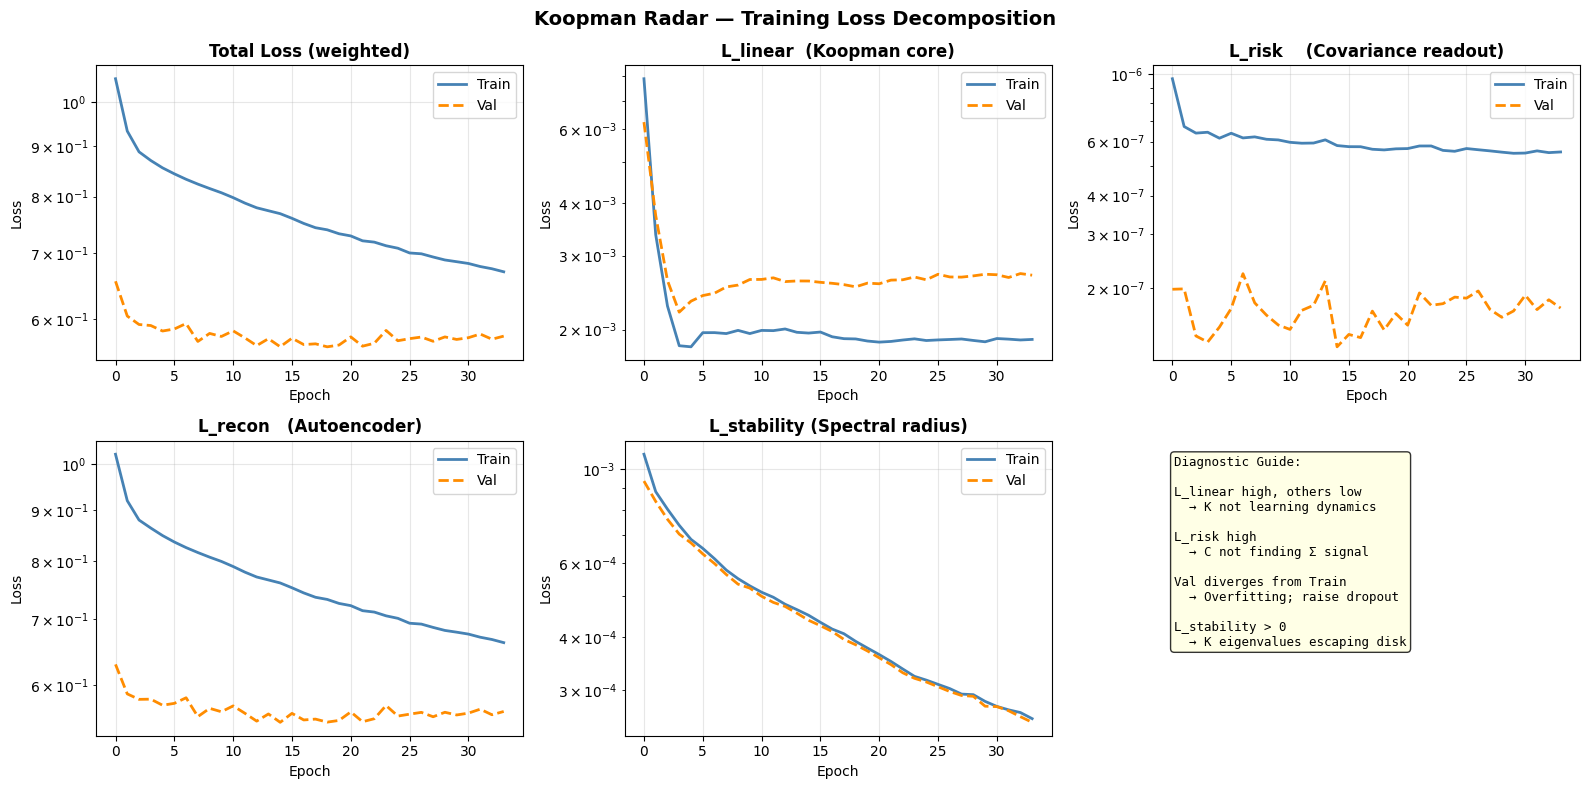

Loss curves saved → koopman_loss_curves.png


In [26]:
plot_loss_curves(history)

## Phase 1 — Step 7: Matrix Extraction & Diagnostics

The neural network phase is now **over**. We extract K, C as plain numpy matrices and discard the neural network weights for Phase 2.

### Diagnostic Checks
- **K eigenspectrum**: All eigenvalues should be inside or near the 0.99-radius disk. Modes outside → forecast diverges over H=7 steps.
- **C readout norms**: Which directions of the latent space drive the covariance prediction most strongly? Large column norms → those latent dimensions carry the most risk signal.
- **Sample Σ prediction**: Visual sanity check — does the predicted heatmap resemble the actual rolling covariance?

K shape : (64, 64)   (latent_dim × latent_dim)
C shape : (841, 64)  (N²  × latent_dim)  [C @ z → vec(Σ)]


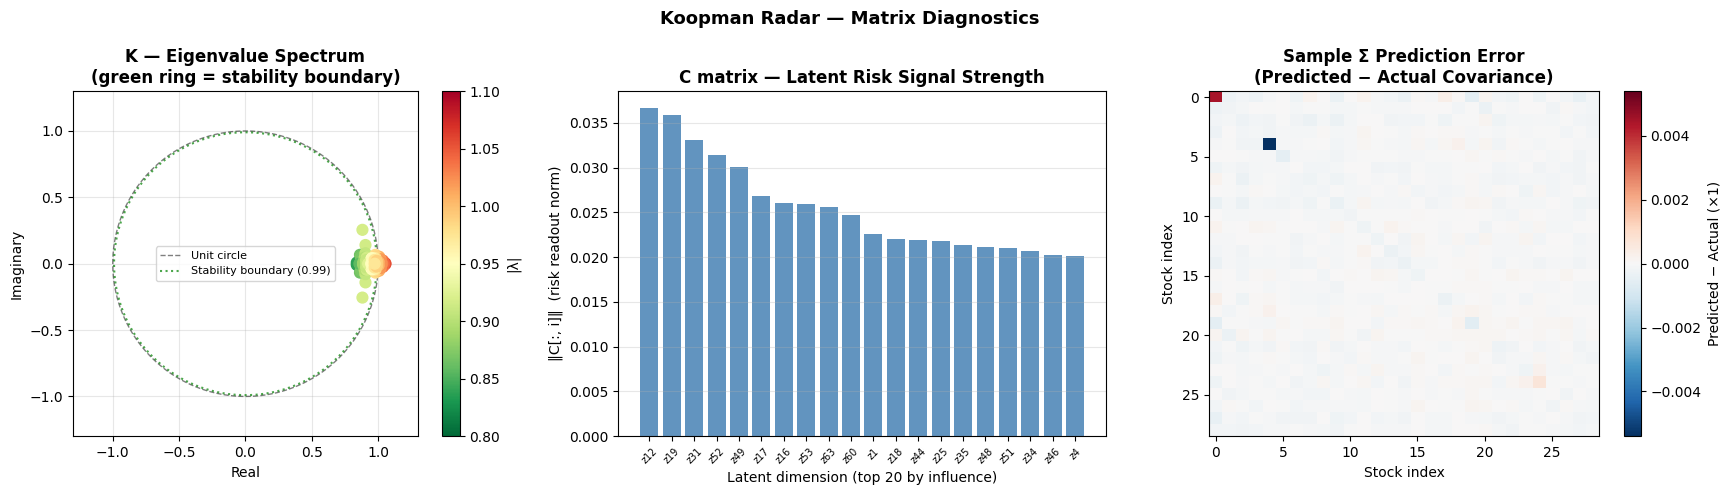


Eigenvalue summary:
  Max  |λ| : 1.0540  (want ≤ 1.00; hard stop at 0.99 in loss)
  Mean |λ| : 0.9556
  Outside stability disk (>0.99): 15/64

K, C saved as .npy  —  Phase 1 Complete.


In [27]:
model.eval()

with torch.no_grad():
    K_np = model.K.weight.cpu().numpy()   # (latent_dim, latent_dim)
    C_np = model.C.weight.cpu().numpy()   # (N*N, latent_dim) — risk readout

print(f'K shape : {K_np.shape}   (latent_dim × latent_dim)')
print(f'C shape : {C_np.shape}  (N²  × latent_dim)  [C @ z → vec(Σ)]')

# ── K eigenspectrum ───────────────────────────────────────────────────────────
eigvals = np.linalg.eigvals(K_np)   # complex
mags    = np.abs(eigvals)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Koopman Radar — Matrix Diagnostics', fontsize=13, fontweight='bold')

# ── Panel 1: K Eigenvalue unit-circle plot ────────────────────────────────────
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1, alpha=0.5, label='Unit circle')
ax.plot(0.99 * np.cos(theta), 0.99 * np.sin(theta), 'g:', lw=1.5, alpha=0.7, label='Stability boundary (0.99)')
sc = ax.scatter(eigvals.real, eigvals.imag, c=mags, cmap='RdYlGn_r',
                vmin=0.8, vmax=1.1, s=60, zorder=5)
plt.colorbar(sc, ax=ax, label='|λ|')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('K — Eigenvalue Spectrum\n(green ring = stability boundary)', fontweight='bold')
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary'); ax.legend(fontsize=8)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)

# ── Panel 2: C column norms — which latent dims drive the risk readout? ────────
ax = axes[1]
c_col_norms = np.linalg.norm(C_np, axis=0)   # (latent_dim,) — influence of each z dimension
top_k = 20
sort_idx = np.argsort(c_col_norms)[::-1][:top_k]
ax.bar(range(top_k), c_col_norms[sort_idx], color='steelblue', alpha=0.85)
ax.set_xticks(range(top_k))
ax.set_xticklabels([f'z{i}' for i in sort_idx], rotation=45, fontsize=7)
ax.set_xlabel('Latent dimension (top 20 by influence)')
ax.set_ylabel('‖C[:, i]‖  (risk readout norm)')
ax.set_title('C matrix — Latent Risk Signal Strength', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 3: Sample Σ prediction vs actual ────────────────────────────────────
# Take a random test window, encode it, predict Σ, compare to actual.
ax = axes[2]
sample_idx = 50   # 50th test sample
x_sample = torch.tensor(
    data_test_n[sample_idx : sample_idx + WINDOW].transpose(1, 0, 2),
    dtype=torch.float32
).unsqueeze(0).to(device)   # (1, N, W, F)

with torch.no_grad():
    z_sample    = model.encoder(x_sample)       # (1, latent_dim)
    Sigma_pred_s = model.decode_sigma(z_sample)  # (1, N, N)

Sigma_pred_np  = Sigma_pred_s.squeeze(0).cpu().numpy()
Sigma_actual_s = estimate_sigma(raw_logret_test[sample_idx : sample_idx + WINDOW], shrinkage=0.2)

# Show difference matrix (predicted − actual)
diff = Sigma_pred_np - Sigma_actual_s
vmax = np.abs(diff).max()
im = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, label='Predicted − Actual (×1)')
ax.set_title('Sample Σ Prediction Error\n(Predicted − Actual Covariance)', fontweight='bold')
ax.set_xlabel('Stock index'); ax.set_ylabel('Stock index')

plt.tight_layout()
plt.savefig('./plots/koopman_matrix_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEigenvalue summary:')
print(f'  Max  |λ| : {mags.max():.4f}  (want ≤ 1.00; hard stop at 0.99 in loss)')
print(f'  Mean |λ| : {mags.mean():.4f}')
print(f'  Outside stability disk (>0.99): {(mags > 0.99).sum()}/{len(mags)}')

np.save('./models/matrices/K_matrix.npy', K_np)
np.save('./models/matrices/C_matrix.npy', C_np)
print('\nK, C saved as .npy  —  Phase 1 Complete.')

## Phase 2 — Risk-Based Model Predictive Control (The Agent)

The deep learning phase is **over**. We use K and C as a deterministic linear pipeline to forecast a 7-day Σ trajectory, then solve a convex QP at each time step.

### The 7-Day Σ Weather Forecast

At time $t$, the K-MPC inference pipeline generates:
$$\Sigma_{t+k} = C(K^k z_t) \quad \text{for} \quad k = 1, \ldots, 7$$

K propagates the latent state autonomously; C decodes each future latent state into a predicted covariance matrix.

### Why the Optimisation Problem is Convex

With $\Sigma_{t+k}$ fixed (a constant PSD matrix at step $k$), the MPC objective:
$$J = \min_{\{u_k\}} \sum_{k=1}^{7} \left[ \underbrace{u_k^T \Sigma_{t+k} u_k}_{\text{convex quadratic}} + \underbrace{\lambda \|u_k - u_{k-1}\|_1}_{\text{convex}} \right]$$

is a sum of convex functions minimised over a convex polytope → **globally optimal solution guaranteed** in milliseconds.

### Rationale for Pure Variance Minimisation

We deliberately omit a return term. As price-takers, our **return predictions are noisy** — the old C matrix that supervised returns had IC well below 0.05 in most markets. Instead, we are highly confident in our **risk forecasts** (covariance structure is more persistent than expected returns). The MPC is therefore a time-varying Global Minimum Variance strategy with transaction friction penalties.

In [28]:
class KoopmanMPC:
    """
    Risk-Based Model Predictive Controller using the Koopman Radar's
    K and C matrices to forecast a 7-day Σ trajectory and solve a
    pure variance-minimisation QP with L1 transaction friction.

    The MPC problem at time t:

        min   Σ_{k=1}^{H} [ u_k^T Σ_{t+k} u_k  +  λ ‖u_k − u_{k-1}‖₁ ]
        s.t.  u_k^T 1 = 1   (fully invested)
              u_k ≥ 0       (long-only)
              u_k ≤ w_max   (diversification cap)

    where Σ_{t+k} = C(K^k z_t) — the neural network's risk forecast.

    This is a Quadratic Program (QP) with L1 penalty on turnover.
    CVXPY reformulates L1 natively; the global optimum is found in milliseconds.
    Execute ONLY the first action u_{t+1}* (receding horizon principle).
    """

    def __init__(self, K: np.ndarray, C_weight: np.ndarray,
                 n_stocks: int, sigma_reg: float,
                 H: int = 7, lambda_tc: float = 0.001,
                 max_weight: float = 0.20):
        self.K          = K
        self.C_weight   = C_weight   # (N*N, latent_dim)
        self.N          = n_stocks
        self.sigma_reg  = sigma_reg
        self.H          = H
        self.lambda_tc  = lambda_tc
        self.max_weight = max_weight

        # Pre-compute K^k matrices for k = 1 … H (inference time is fixed)
        self._Kpow = []
        Kk = K.copy()
        for _ in range(H):
            self._Kpow.append(Kk.copy())
            Kk = Kk @ K

    def _forecast_sigmas(self, z0: np.ndarray) -> list:
        """
        Generate the 7-day Σ weather forecast.

        Σ_{t+k} = C(K^k z_t)  for k = 1, …, H
        Each Σ is symmetrised and projected to PD via eigenvalue clipping.

        Returns list of H (N, N) numpy arrays.
        """
        sigmas = []
        for Kk in self._Kpow:
            z_k   = Kk @ z0                                    # (latent_dim,)
            raw   = self.C_weight @ z_k                        # (N*N,)
            A     = raw.reshape(self.N, self.N)
            Sigma = (A + A.T) / 2.0 + self.sigma_reg * np.eye(self.N)
            # Project to PD by clipping negative eigenvalues
            evals, evecs = np.linalg.eigh(Sigma)
            evals  = np.maximum(evals, 1e-6)
            Sigma  = evecs @ np.diag(evals) @ evecs.T
            sigmas.append(Sigma)
        return sigmas   # list of H (N, N) arrays

    def solve(self, z_t: np.ndarray, u_prev: np.ndarray) -> np.ndarray:
        """
        Solve the risk-based MPC problem and return the first action u_{t+1}*.

        Args:
            z_t    : (latent_dim,) current latent state from the encoder
            u_prev : (N,) current portfolio weights (transaction cost baseline)
        Returns:
            u_star : (N,) optimal portfolio for the next period
        """
        sigmas = self._forecast_sigmas(z_t)   # H forecasted (N, N) matrices

        # CVXPY decision variables — one weight vector per horizon step
        # Variables: u_1, …, u_H  (decisions for days t+1 through t+H)
        U = [cp.Variable(self.N, name=f'u_{k+1}') for k in range(self.H)]

        objective_terms = []
        for k in range(self.H):
            u_km1 = u_prev if k == 0 else U[k - 1]

            # Predicted portfolio variance under forecasted Σ_{t+k+1}
            predicted_variance = cp.quad_form(U[k], sigmas[k])   # convex quadratic

            # L1 kinematic friction — penalises rebalancing
            turnover_cost = cp.norm1(U[k] - u_km1)               # convex

            objective_terms.append(predicted_variance + self.lambda_tc * turnover_cost)

        obj = cp.Minimize(sum(objective_terms))

        # Constraints (applied to every u_k in the horizon)
        constraints = []
        for k in range(self.H):
            constraints.append(cp.sum(U[k]) == 1)           # fully invested
            constraints.append(U[k] >= 0)                   # long-only
            constraints.append(U[k] <= self.max_weight)     # diversification cap

        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver=cp.CLARABEL, verbose=False)
        except Exception:
            prob.solve(solver=cp.ECOS, verbose=False)

        # If solver fails, fall back to equal-weight portfolio
        if prob.status not in ('optimal', 'optimal_inaccurate') or U[0].value is None:
            return np.full(self.N, 1.0 / self.N)

        # Return only the FIRST action (receding horizon principle)
        u_star = np.array(U[0].value, dtype=np.float64)
        # Clip small negatives from solver tolerance, renormalise
        u_star = np.clip(u_star, 0, 1)
        u_star /= u_star.sum()
        return u_star


In [29]:
# ── Quick solve test ──────────────────────────────────────────────────────────
print('Testing risk-based MPC solver...')
mpc_test = KoopmanMPC(
    K=K_np, C_weight=C_np, n_stocks=N_STOCKS,
    sigma_reg=SIGMA_REG, H=H, lambda_tc=LAMBDA_TC, max_weight=MAX_WEIGHT
)
z_dummy = np.random.randn(LATENT_DIM)
u_dummy = np.full(N_STOCKS, 1.0 / N_STOCKS)
u_test  = mpc_test.solve(z_dummy, u_dummy)

print(f'Solver status : OK')
print(f'u_star sum    : {u_test.sum():.6f}  (should be 1.0)')
print(f'u_star min    : {u_test.min():.4f}  (should be ≥ 0)')
print(f'u_star max    : {u_test.max():.4f}  (should be ≤ {MAX_WEIGHT})')
print(f'Non-zero positions : {(u_test > 1e-4).sum()}')
del z_dummy, u_dummy, u_test, mpc_test

Testing risk-based MPC solver...
Solver status : OK
u_star sum    : 1.000000  (should be 1.0)
u_star min    : 0.0069  (should be ≥ 0)
u_star max    : 0.0850  (should be ≤ 0.2)
Non-zero positions : 29


## Phase 3 — Convex Execution: Rolling Backtest

### Per-Day Receding Horizon Loop
1. Observe market window `x_t` → **Encode** → latent state `z_t`
2. **Forecast** 7-day Σ trajectory: `{Σ_{t+1}, …, Σ_{t+7}}` = `{C(K¹z_t), …, C(K⁷z_t)}`
3. Pass Σ trajectory to **CVXPY** risk-based MPC solver
4. CVXPY returns mathematically guaranteed global-optimal `u_t*` in milliseconds
5. **Execute only `u_t*`** — the first action in the optimal 7-day plan
6. Roll forward to t+1, ingest new market data, repeat

**Transaction costs**: 10 bps per unit of turnover (|Δweight|) applied to all backtest returns.

**No rolling covariance window**: The Σ comes entirely from the neural network's forecast — this is the key difference from the previous architecture.

In [30]:
def encode_window(model, window_np: np.ndarray, device) -> np.ndarray:
    """Encode a single (N, W, F) numpy window → z (latent_dim,) numpy."""
    model.eval()
    with torch.no_grad():
        x = torch.tensor(window_np, dtype=torch.float32).unsqueeze(0).to(device)  # (1, N, W, F)
        z = model.encoder(x)   # (1, latent_dim)
    return z.squeeze(0).cpu().numpy()


In [33]:
def run_backtest(model, data_norm, log_returns_raw,
                               K_np, C_np, tickers,
                               window, H, lambda_tc, max_weight, sigma_reg, device):
    N  = len(tickers)
    T  = data_norm.shape[0]
    results = []

    print(f'Pre-computing all {T - window} latent states on GPU...')

    # 1. Vectorize the rolling window extraction
    # Create an array of shape (T-window, N, W, F)
    all_windows = np.array([
        data_norm[t - window : t].transpose(1, 0, 2)
        for t in range(window, T)
    ])

    # 2. Push the entire block to the GPU and encode in one pass
    model.eval()
    with torch.no_grad():
        windows_tensor = torch.tensor(all_windows, dtype=torch.float32).to(device)
        # Bypassing the CPU/GPU transfer bottleneck
        all_z_t = model.encoder(windows_tensor).cpu().numpy()

    u_prev  = np.full(N, 1.0 / N)
    mpc     = KoopmanMPC(
        K=K_np, C_weight=C_np, n_stocks=N,
        sigma_reg=sigma_reg, H=H,
        lambda_tc=lambda_tc, max_weight=max_weight
    )

    print('Running sequential MPC execution...')

    # 3. The CVXPY loop remains sequential, but now only does CPU math
    for i, t in enumerate(range(window, T)):
        z_t = all_z_t[i] # Instant O(1) lookup

        u_star = mpc.solve(z_t, u_prev)

        r_t       = log_returns_raw[t, :]
        ret_gross = float(u_star @ r_t)
        ret_ew    = float(r_t.mean())
        turnover  = np.abs(u_star - u_prev).sum()
        cost      = turnover * lambda_tc
        ret_net   = ret_gross - cost

        results.append({
            'ret_mpc_gross': ret_gross,
            'ret_mpc_net'  : ret_net,
            'cost'         : cost,
            'ret_ew'       : ret_ew,
            'turnover'     : turnover,
        })
        u_prev = u_star

        if (i + 1) % 100 == 0:
            print(f'  Day {i + 1}/{T - window}  |  last u_star max={u_star.max():.3f}')

    print('Backtest complete.')
    return pd.DataFrame(results)


print('Backtest function defined.')

Backtest function defined.


In [34]:
# ── Prepare test-period raw log returns (denormalised) ────────────────────────
test_log_returns_raw = (
    data_test_n[:, :, LOGRET_IDX] * train_std[LOGRET_IDX] + train_mean[LOGRET_IDX]
)  # (T_test, N_stocks)  — actual daily log returns in test period

date_index_test = pd.to_datetime(
    np.load('./data/date_index_test.npy', allow_pickle=True)
)

# ── Run backtest ──────────────────────────────────────────────────────────────
bt_df = run_backtest(
    model=model,
    data_norm=data_test_n,
    log_returns_raw=test_log_returns_raw,
    K_np=K_np, C_np=C_np,
    tickers=TICKERS,
    window=WINDOW,
    H=H,
    lambda_tc=LAMBDA_TC,
    max_weight=MAX_WEIGHT,
    sigma_reg=SIGMA_REG,
    device=device,
)

# Attach dates (signal dates start at WINDOW-th day of test period)
signal_dates = date_index_test[WINDOW:]
bt_df.index  = signal_dates[:len(bt_df)]
bt_df.index.name = 'date'

# ── Add benchmark ─────────────────────────────────────────────────────────────
bse = yf.download(DATA_BENCHMARKS[1], start=date_index_test[0], end=date_index_test[-1],
                  auto_adjust=True, progress=False)
bse_ret = np.log(bse['Close'] / bse['Close'].shift(1)).dropna()
bt_df['ret_bench'] = bse_ret.reindex(bt_df.index).fillna(0).values

bt_df.to_csv('./results/mpc_backtest_results.csv')
print(f'\nBacktest shape : {bt_df.shape}')
print(bt_df.head())

Pre-computing all 480 latent states on GPU...
Running sequential MPC execution...
  Day 100/480  |  last u_star max=0.163
  Day 200/480  |  last u_star max=0.177
  Day 300/480  |  last u_star max=0.177
  Day 400/480  |  last u_star max=0.177
Backtest complete.

Backtest shape : (480, 6)
            ret_mpc_gross  ret_mpc_net          cost    ret_ew      turnover  \
date                                                                           
2023-01-16      -0.002327    -0.002354  2.668080e-05 -0.002257  2.668080e-02   
2023-01-17       0.006701     0.006701  3.385396e-13  0.006283  3.385396e-10   
2023-01-18       0.005186     0.005186  2.467474e-11  0.005443  2.467474e-08   
2023-01-19      -0.004827    -0.004827  1.803701e-12 -0.004546  1.803701e-09   
2023-01-20      -0.007621    -0.007621  1.174110e-11 -0.007163  1.174110e-08   

            ret_bench  
date                   
2023-01-16  -0.002795  
2023-01-17   0.009321  
2023-01-18   0.006409  
2023-01-19  -0.003073  
2023-01

## Phase 3 — Performance Analytics

In [35]:
def performance_stats(daily_log_returns: pd.Series, ann_factor: int = 252) -> dict:
    """Compute annualised performance statistics from a daily log-return series."""
    r  = daily_log_returns.dropna()
    cum_wealth = np.exp(r.cumsum())

    # CAGR
    total_ret  = cum_wealth.iloc[-1] - 1
    n_years    = len(r) / ann_factor
    cagr       = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0

    # Volatility & Sharpe  (annualised, log-return approximation)
    ann_vol    = r.std() * np.sqrt(ann_factor)
    ann_ret    = r.mean() * ann_factor
    sharpe     = ann_ret / (ann_vol + 1e-9)

    # Maximum drawdown
    running_max = cum_wealth.cummax()
    drawdown    = (cum_wealth - running_max) / running_max
    max_dd      = drawdown.min()

    # Calmar
    calmar     = cagr / (abs(max_dd) + 1e-9)

    # Win rate (% of days with positive return)
    win_rate   = (r > 0).mean()

    return dict(
        CAGR=cagr, Ann_Vol=ann_vol, Sharpe=sharpe,
        Max_DD=max_dd, Calmar=calmar, Win_Rate=win_rate,
        Total_Return=total_ret, N_Days=len(r)
    )


## Phase 3 — Markowitz GMV vs K-MPC Comparison

This section adds the **classical Markowitz Global Minimum Variance (GMV)** portfolio as a fourth comparator alongside the K-MPC, equal-weight, and BSE Sensex benchmark.

The GMV portfolio solves the same pure variance-minimisation problem as the K-MPC but uses a **rolling historical covariance window** (60 days, Ledoit-Oja shrinkage α=0.2 (matches MPC training)) instead of the neural network's forward-looking Σ forecast. This isolates the contribution of the Koopman radar's predictive covariance model vs simple backward-looking estimation.

| Feature | K-MPC | Markowitz GMV |
|---|---|---|
| **Σ estimation** | Neural forecast: C(Kᵏzₜ) | Rolling sample covariance |
| **Horizon** | 7-day planning horizon | Single-period |
| **Transaction cost** | λ·‖Δu‖₁ in objective | Applied post-hoc |
| **Constraints** | sum=1, long-only, u≤w_max | sum=1, long-only, u≤w_max |
| **Solver** | CVXPY / CLARABEL | CVXPY / CLARABEL |

In [36]:
# ── Markowitz Minimum-Variance Portfolio — Rolling Backtest ───────────────────
# The classical Markowitz Global Minimum Variance (GMV) portfolio solves:
#
#   min  u^T Σ u
#   s.t. u^T 1 = 1,  u ≥ 0,  u ≤ w_max
#
# Σ is estimated from a rolling historical window of log returns (no neural
# network — purely classical).  This gives a direct apples-to-apples comparison
# between the Koopman K-MPC (which forecasts Σ) and the classical approach
# (which uses the same shrinkage estimator but looks only backward).
#
# Alignment with MPC:
#   The GMV backtest starts from the same day as the MPC (t = WINDOW = 10).
#   For early days where fewer than GMV_WINDOW test-period returns are available,
#   we pad with the tail of the training log-returns so the covariance estimate
#   always uses a full GMV_WINDOW-day window.  This avoids the 50-day gap that
#   would result from waiting for GMV_WINDOW test days to accumulate, and ensures
#   all strategies are evaluated over an identical date range.
#
# Implementation notes:
#  • Rolling window length = 60 trading days  (≈ 3 months of data)
#  • Same shrinkage as MPC training: estimate_sigma() with α = 0.2
#  • Same long-only + max-weight + sum-to-1 constraints as the MPC
#  • 10-bps transaction cost on turnover for a fair net-return comparison
#  • CVXPY / CLARABEL solver — identical infrastructure to KoopmanMPC

GMV_WINDOW = 60   # rolling lookback length (days) — not the start offset

# Tail of training log-returns used to pad early test windows
train_logret_tail = raw_logret_train[-GMV_WINDOW:]   # (GMV_WINDOW, N)

def run_gmv_backtest(log_returns_raw, train_tail, dates,
                     start_offset, lambda_tc=LAMBDA_TC, max_weight=MAX_WEIGHT):
    """
    Rolling Markowitz GMV backtest aligned to the MPC start date.

    For day t in the test period (0-indexed):
      - If t >= GMV_WINDOW: use pure test-period window  log_returns_raw[t-GMV_WINDOW:t]
      - If t <  GMV_WINDOW: pad with training tail so the window is always GMV_WINDOW long
                            [train_tail[-(GMV_WINDOW-t):], log_returns_raw[:t]]

    Args:
        log_returns_raw : (T, N) test-period daily log returns
        train_tail      : (GMV_WINDOW, N) tail of training log returns for padding
        dates           : pd.DatetimeIndex aligned to log_returns_raw
        start_offset    : first t to trade (= WINDOW, to match MPC start date)
        lambda_tc       : transaction cost per unit turnover
        max_weight      : maximum single-stock weight
    Returns:
        pd.DataFrame indexed by signal dates, columns: ret_gmv_gross, ret_gmv_net, cost, turnover
    """
    T, N   = log_returns_raw.shape
    u_prev = np.full(N, 1.0 / N)
    results = []

    n_signal = T - start_offset
    print(f"Running GMV backtest over {n_signal} signal days "
          f"(window = {GMV_WINDOW} days, start_offset = {start_offset})...")

    for t in range(start_offset, T):
        # ── 1. Build GMV_WINDOW-length return window (pad with train tail if needed) ──
        if t >= GMV_WINDOW:
            ret_window = log_returns_raw[t - GMV_WINDOW : t]          # pure test data
        else:
            n_from_test  = t
            n_from_train = GMV_WINDOW - n_from_test
            ret_window   = np.vstack([
                train_tail[-n_from_train:],          # pad from training tail
                log_returns_raw[:n_from_test],        # available test data
            ])   # always shape (GMV_WINDOW, N)

        Sigma_est = estimate_sigma(ret_window, shrinkage=0.2)

        # ── 2. Solve Markowitz GMV QP ─────────────────────────────────────────
        u = cp.Variable(N)
        objective = cp.Minimize(cp.quad_form(u, Sigma_est))
        constraints = [
            cp.sum(u) == 1,
            u >= 0,
            u <= max_weight,
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.CLARABEL, verbose=False)
        except Exception:
            prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status not in ("optimal", "optimal_inaccurate") or u.value is None:
            u_star = u_prev.copy()
        else:
            u_star = np.clip(np.array(u.value, dtype=np.float64), 0, 1)
            u_star /= u_star.sum()

        # ── 3. Realised return on day t ───────────────────────────────────────
        r_t       = log_returns_raw[t, :]
        ret_gross = float(u_star @ r_t)
        turnover  = np.abs(u_star - u_prev).sum()
        cost      = turnover * lambda_tc
        ret_net   = ret_gross - cost

        results.append({
            "ret_gmv_gross": ret_gross,
            "ret_gmv_net":   ret_net,
            "cost":          cost,
            "turnover":      turnover,
        })
        u_prev = u_star

        if (t - start_offset + 1) % 100 == 0:
            print(f"  Day {t - start_offset + 1}/{n_signal}  |  "
                  f"u_star max={u_star.max():.3f}  eff.positions={(u_star > 1e-4).sum()}")

    print("GMV backtest complete.")

    # Index by signal dates — identical to bt_df.index
    gmv_dates = dates[start_offset : start_offset + len(results)]
    df = pd.DataFrame(results, index=gmv_dates)
    df.index.name = "date"
    return df


# ── Run GMV backtest (aligned to MPC start) ───────────────────────────────────
gmv_df = run_gmv_backtest(
    log_returns_raw = test_log_returns_raw,
    train_tail      = train_logret_tail,
    dates           = date_index_test,
    start_offset    = WINDOW,          # same start as MPC — no trimming needed
    lambda_tc       = LAMBDA_TC,
    max_weight      = MAX_WEIGHT,
)

Running GMV backtest over 480 signal days (window = 60 days, start_offset = 10)...
  Day 100/480  |  u_star max=0.130  eff.positions=21
  Day 200/480  |  u_star max=0.200  eff.positions=22
  Day 300/480  |  u_star max=0.107  eff.positions=21
  Day 400/480  |  u_star max=0.142  eff.positions=17
GMV backtest complete.


In [37]:

# Sanity check: GMV and MPC should share exactly the same index
assert gmv_df.index.equals(bt_df.index),     f"Index mismatch: GMV {gmv_df.index[0]} → {gmv_df.index[-1]}, "     f"MPC {bt_df.index[0]} → {bt_df.index[-1]}"

print(f"\nGMV backtest shape : {gmv_df.shape}")
print(f"Evaluation window  : {gmv_df.index[0].date()} → {gmv_df.index[-1].date()}")
print(f"Matches MPC window : {gmv_df.index.equals(bt_df.index)}")
print(gmv_df.head())



GMV backtest shape : (480, 4)
Evaluation window  : 2023-01-16 → 2024-12-30
Matches MPC window : True
            ret_gmv_gross  ret_gmv_net      cost  turnover
date                                                      
2023-01-16      -0.002003    -0.003163  0.001160  1.160180
2023-01-17       0.013275     0.013148  0.000127  0.126545
2023-01-18       0.005037     0.004899  0.000138  0.137816
2023-01-19      -0.007720    -0.007773  0.000053  0.053080
2023-01-20      -0.013784    -0.014098  0.000315  0.314747


In [38]:

# ── All strategies on identical date range (no trimming required) ─────────────
strategies_full = {
    "MPC (gross)":  bt_df["ret_mpc_gross"],
    "MPC (net)":    bt_df["ret_mpc_net"],
    "GMV (gross)":  gmv_df["ret_gmv_gross"],
    "GMV (net)":    gmv_df["ret_gmv_net"],
    "Equal Weight": bt_df["ret_ew"],
    "Benchmark":   bt_df["ret_bench"],
}


# ── Performance table — all strategies ───────────────────────────────────────
print("\n" + "=" * 88)
print(f"  {'Strategy':<20} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} "
      f"{'MaxDD':>9} {'Calmar':>8} {'Win%':>7} {'N_Days':>7}")
print("-" * 88)
for name, ret_series in strategies_full.items():
    s = performance_stats(ret_series)
    mdd_flag = "▲" if s["Max_DD"] < -0.20 else " "
    print(f"  {name:<20} {s['CAGR']:>8.2%} {s['Ann_Vol']:>8.2%} "
          f"{s['Sharpe']:>8.2f} {s['Max_DD']:>9.2%}{mdd_flag} "
          f"{s['Calmar']:>8.2f} {s['Win_Rate']:>7.1%} {s['N_Days']:>7,}")
print("=" * 88)
print("  ▲  Max Drawdown exceeds 20%")


  Strategy                 CAGR      Vol   Sharpe     MaxDD   Calmar    Win%  N_Days
----------------------------------------------------------------------------------------
  MPC (gross)            26.02%   12.30%     1.88   -10.06%      2.59   56.0%     480
  MPC (net)              25.90%   12.30%     1.87   -10.07%      2.57   56.0%     480
  GMV (gross)            22.66%   10.77%     1.90   -13.88%      1.63   57.1%     480
  GMV (net)              19.21%   10.76%     1.63   -14.29%      1.34   55.8%     480
  Equal Weight           18.18%   12.57%     1.33   -12.07%      1.51   56.0%     480
  Benchmark              15.04%   12.16%     1.15   -10.11%      1.49   56.2%     480
  ▲  Max Drawdown exceeds 20%


In [39]:

# ── Save extended results ─────────────────────────────────────────────────────
combined = bt_df[["ret_mpc_gross", "ret_mpc_net", "ret_ew", "ret_bench"]].copy()
combined["ret_gmv_gross"] = gmv_df["ret_gmv_gross"]
combined["ret_gmv_net"]   = gmv_df["ret_gmv_net"]
combined.to_csv("./results/all_strategies_backtest.csv")
print("\nExtended results saved → results/all_strategies_backtest.csv")


Extended results saved → results/all_strategies_backtest.csv


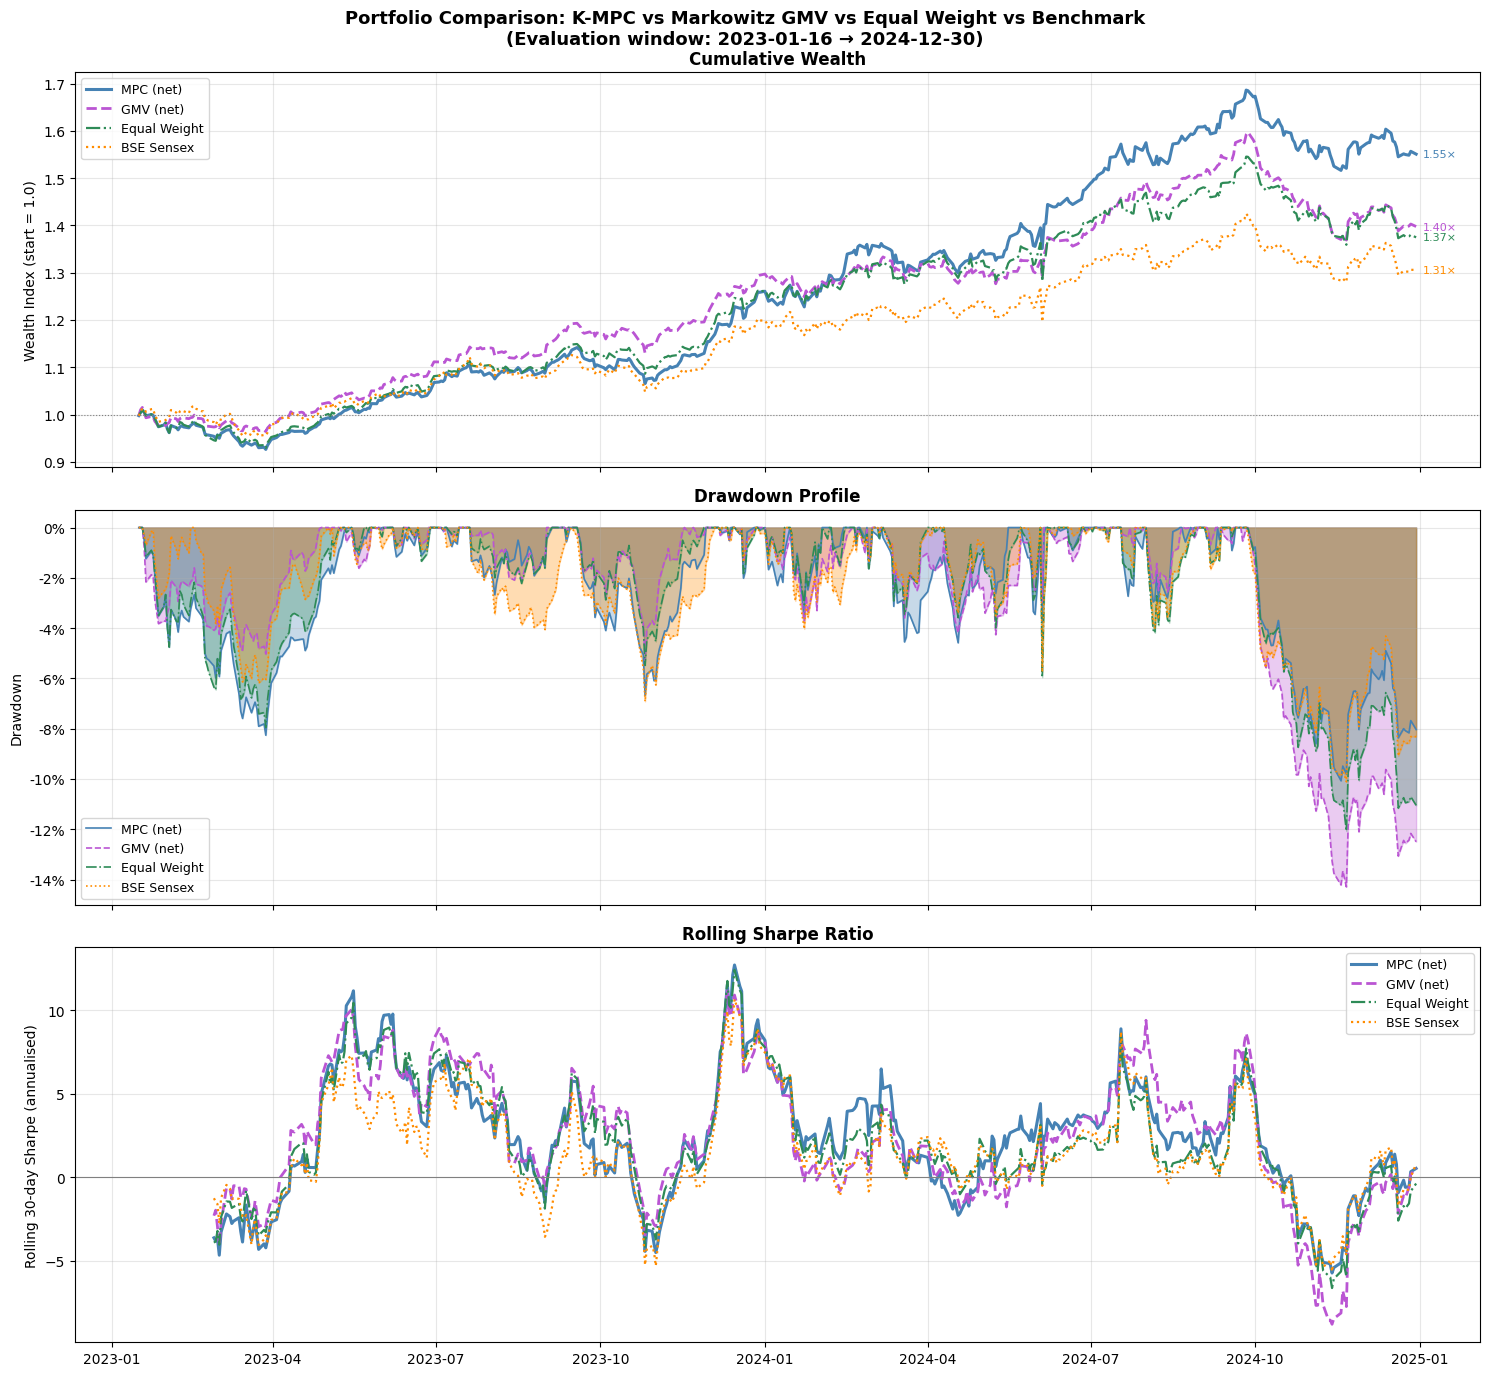

4-strategy comparison plot saved → plots/gmv_vs_mpc_comparison.png


In [40]:


# ── Visualisation: 4-strategy performance dashboard ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
fig.suptitle(
    "Portfolio Comparison: K-MPC vs Markowitz GMV vs Equal Weight vs Benchmark\n"
    f"(Evaluation window: {gmv_df.index[0].date()} → {gmv_df.index[-1].date()})",
    fontsize=13, fontweight="bold"
)

plot_strategies = {
    "MPC (net)":    (bt_df["ret_mpc_net"],   "steelblue",    "-",  2.2),
    "GMV (net)":    (gmv_df["ret_gmv_net"],  "mediumorchid", "--", 2.0),
    "Equal Weight": (bt_df["ret_ew"],         "seagreen",     "-.", 1.6),
    "BSE Sensex":   (bt_df["ret_bench"],      "darkorange",   ":",  1.6),
}

# ── Panel 1: Cumulative wealth ────────────────────────────────────────────────
ax = axes[0]
for name, (ret, col, ls, lw) in plot_strategies.items():
    cum = np.exp(ret.cumsum())
    ax.plot(cum.index, cum.values, lw=lw, color=col, ls=ls, label=name)
ax.axhline(1.0, color="grey", lw=0.8, ls=":")
ax.set_ylabel("Wealth Index (start = 1.0)")
ax.set_title("Cumulative Wealth", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
for name, (ret, col, ls, lw) in plot_strategies.items():
    cum = np.exp(ret.cumsum())
    ax.annotate(
        f"{cum.iloc[-1]:.2f}×",
        xy=(cum.index[-1], cum.iloc[-1]),
        xytext=(5, 0), textcoords="offset points",
        color=col, fontsize=8, va="center"
    )

# ── Panel 2: Drawdown ─────────────────────────────────────────────────────────
ax = axes[1]
for name, (ret, col, ls, lw) in plot_strategies.items():
    cum = np.exp(ret.cumsum())
    dd  = (cum - cum.cummax()) / cum.cummax()
    ax.fill_between(dd.index, dd.values, 0, alpha=0.30, color=col)
    ax.plot(dd.index, dd.values, lw=1.2, color=col, ls=ls, label=name)
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown Profile", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: Rolling 30-day Sharpe ───────────────────────────────────────────
ax = axes[2]
for name, (ret, col, ls, lw) in plot_strategies.items():
    roll_sr = (
        ret.rolling(30).mean() / (ret.rolling(30).std() + 1e-9)
    ) * np.sqrt(252)
    ax.plot(roll_sr.index, roll_sr.values, lw=lw, color=col, ls=ls, label=name)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Rolling 30-day Sharpe (annualised)")
ax.set_title("Rolling Sharpe Ratio", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.savefig("./plots/gmv_vs_mpc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("4-strategy comparison plot saved → plots/gmv_vs_mpc_comparison.png")



Computing daily predicted portfolio variance for GMV vs MPC...


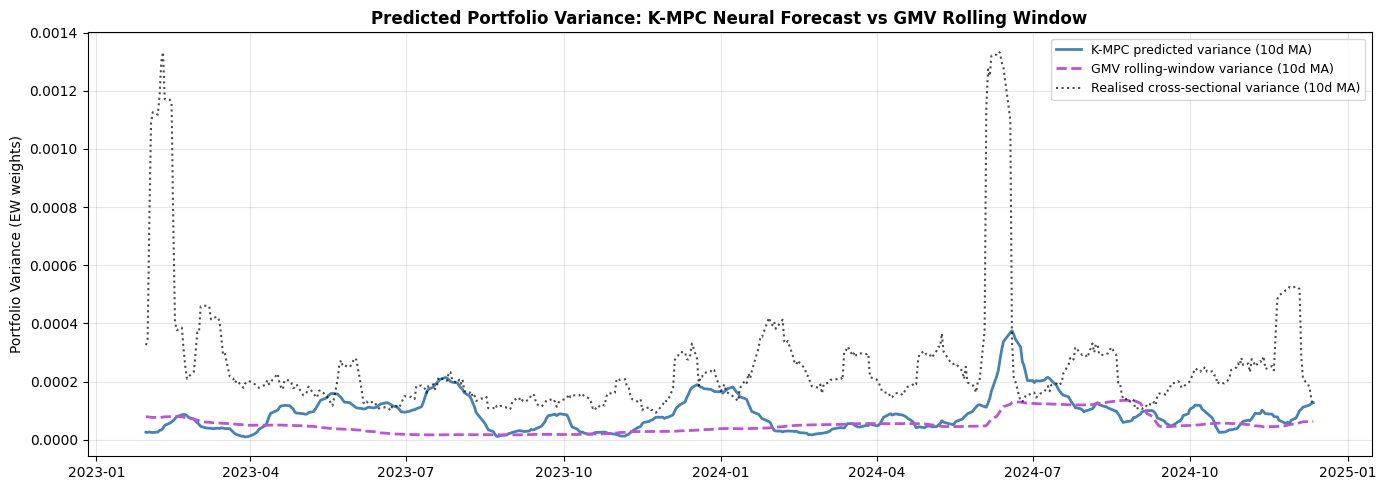

Variance forecast comparison plot saved → plots/gmv_vs_mpc_variance_forecast.png


In [41]:

# ── Σ Forecast comparison: GMV rolling-window vs K-MPC neural forecast ────────
print("\nComputing daily predicted portfolio variance for GMV vs MPC...")

gmv_pred_var, mpc_pred_var, realised_var = [], [], []
u_g = np.full(N_STOCKS, 1.0 / N_STOCKS)
mpc_var_obj = KoopmanMPC(
    K=K_np, C_weight=C_np, n_stocks=N_STOCKS,
    sigma_reg=SIGMA_REG, H=H, lambda_tc=LAMBDA_TC, max_weight=MAX_WEIGHT
)

model.eval()
with torch.no_grad():
    for t in range(WINDOW, data_test_n.shape[0] - WINDOW - 1):
        # GMV: padded rolling window (same logic as backtest)
        if t >= GMV_WINDOW:
            ret_w = test_log_returns_raw[t - GMV_WINDOW : t]
        else:
            n_from_test  = t
            n_from_train = GMV_WINDOW - n_from_test
            ret_w = np.vstack([train_logret_tail[-n_from_train:],
                               test_log_returns_raw[:n_from_test]])
        Sg_gmv = estimate_sigma(ret_w, shrinkage=0.2)
        gmv_pred_var.append(float(u_g @ Sg_gmv @ u_g))

        # K-MPC: neural 1-step-ahead Σ forecast
        win_np = data_test_n[t - WINDOW : t].transpose(1, 0, 2)
        z_t_   = encode_window(model, win_np, device)
        Sg_mpc = mpc_var_obj._forecast_sigmas(z_t_)[0]
        mpc_pred_var.append(float(u_g @ Sg_mpc @ u_g))

        # Realised next-day cross-sectional variance proxy
        realised_var.append(float((test_log_returns_raw[t, :] ** 2).mean()))

pred_dates = date_index_test[WINDOW : WINDOW + len(gmv_pred_var)]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pred_dates, pd.Series(mpc_pred_var, index=pred_dates).rolling(10).mean(),
        lw=2, color="steelblue",    label="K-MPC predicted variance (10d MA)")
ax.plot(pred_dates, pd.Series(gmv_pred_var, index=pred_dates).rolling(10).mean(),
        lw=2, color="mediumorchid", ls="--", label="GMV rolling-window variance (10d MA)")
ax.plot(pred_dates, pd.Series(realised_var, index=pred_dates).rolling(10).mean(),
        lw=1.5, color="black", ls=":", alpha=0.7, label="Realised cross-sectional variance (10d MA)")
ax.set_title("Predicted Portfolio Variance: K-MPC Neural Forecast vs GMV Rolling Window",
             fontweight="bold")
ax.set_ylabel("Portfolio Variance (EW weights)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig("./plots/gmv_vs_mpc_variance_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Variance forecast comparison plot saved → plots/gmv_vs_mpc_variance_forecast.png")

Computing Σ forecast quality diagnostics...

  RISK FORECAST QUALITY — C matrix (Σ Readout)
  Mean Frobenius error : 7.4628e-03
  Mean relative error  : 3.1175   (lower is better)
  Mean diag corr       : +0.0920   (variance ranking; target > 0.3)
  Diag corr > 0        : 59.1%


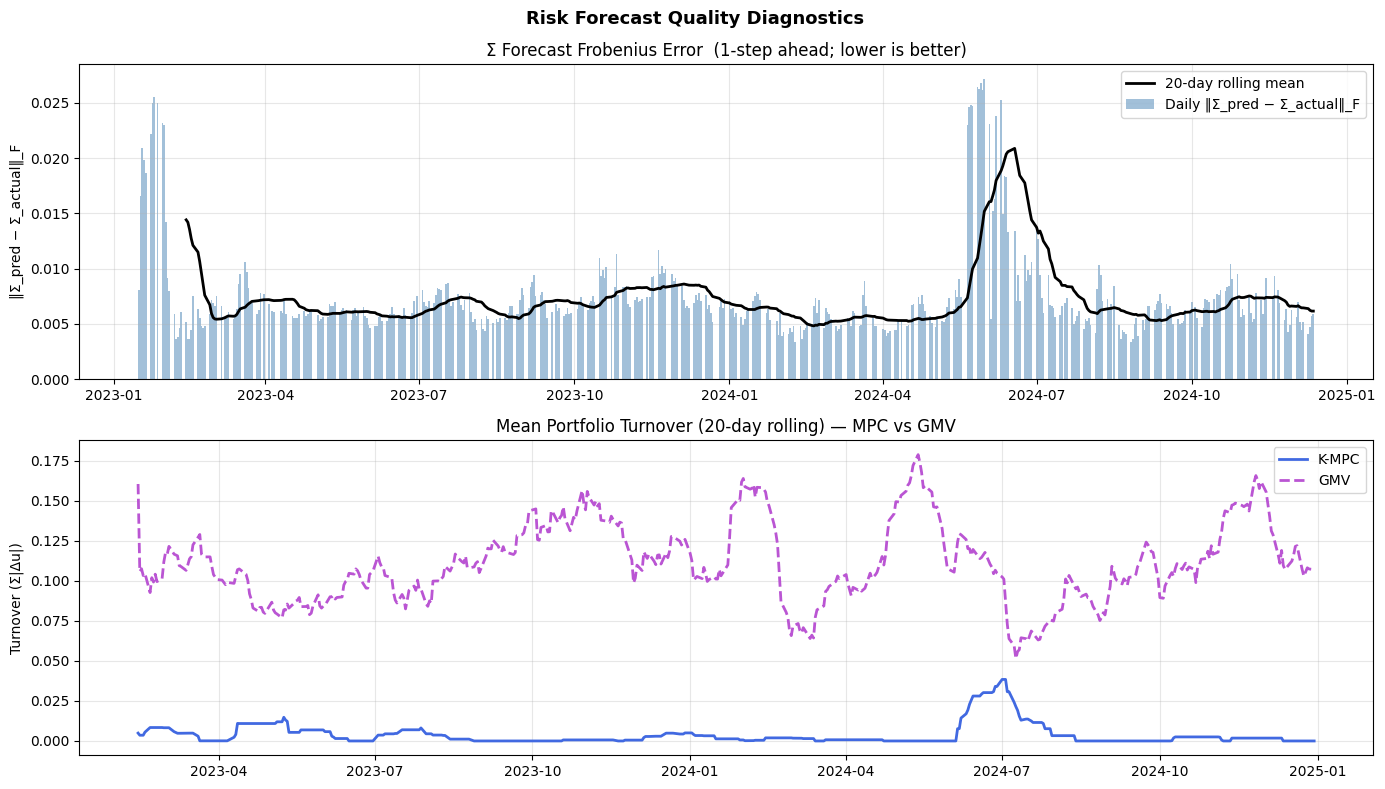

Plot saved → signal_quality.png


In [42]:
# ── Σ Forecast Quality — Covariance Prediction Diagnostics ────────────────
# Analogous to the old IC analysis, but for the risk radar:
#   For each test day t:
#     1. Encode z_t
#     2. Forecast Σ_{t+1} = C(K^1 z_t)  (1-step ahead)
#     3. Compute actual Σ_{t+1} = shrunk_cov(log_returns[t+1 : t+1+WINDOW])
#     4. Record Frobenius error ‖Σ_pred − Σ_actual‖_F
# Also record the relative error and the diagonal accuracy (variance forecast).

print('Computing Σ forecast quality diagnostics...')

frob_errors   = []
rel_errors    = []
diag_corrs    = []   # Pearson corr between predicted and actual diagonal (variance)

# Pre-compute K^1 for 1-step-ahead forecast
K1 = K_np.copy()

model.eval()
with torch.no_grad():
    for t in range(WINDOW, data_test_n.shape[0] - WINDOW - 1):
        # Encode current window
        win_np   = data_test_n[t - WINDOW : t].transpose(1, 0, 2)   # (N, W, F)
        z_t      = encode_window(model, win_np, device)              # (latent_dim,)

        # 1-step-ahead Σ forecast
        z_t1_pred   = K1 @ z_t
        raw_pred     = C_np @ z_t1_pred   # (N*N,)
        A_pred       = raw_pred.reshape(N_STOCKS, N_STOCKS)
        Sigma_pred_t = (A_pred + A_pred.T) / 2.0 + SIGMA_REG * np.eye(N_STOCKS)

        # Actual Σ_{t+1}
        if t + 1 + WINDOW <= raw_logret_test.shape[0]:
            Sigma_actual_t = estimate_sigma(
                raw_logret_test[t + 1 : t + 1 + WINDOW], shrinkage=0.2
            )
        else:
            continue

        # Frobenius error
        diff = Sigma_pred_t - Sigma_actual_t
        frob = np.linalg.norm(diff, 'fro')
        frob_errors.append(frob)

        # Relative Frobenius error
        denom = np.linalg.norm(Sigma_actual_t, 'fro') + 1e-10
        rel_errors.append(frob / denom)

        # Diagonal correlation (variance forecast quality)
        pred_diag   = np.diag(Sigma_pred_t)
        actual_diag = np.diag(Sigma_actual_t)
        if pred_diag.std() > 1e-10 and actual_diag.std() > 1e-10:
            corr = np.corrcoef(pred_diag, actual_diag)[0, 1]
            diag_corrs.append(corr)
        else:
            diag_corrs.append(np.nan)

frob_arr  = np.array(frob_errors)
rel_arr   = np.array(rel_errors)
diag_arr  = np.array(diag_corrs)

print(f'\n{"="*50}')
print(f'  RISK FORECAST QUALITY — C matrix (Σ Readout)')
print(f'{"="*50}')
print(f'  Mean Frobenius error : {frob_arr.mean():.4e}')
print(f'  Mean relative error  : {rel_arr.mean():.4f}   (lower is better)')
print(f'  Mean diag corr       : {np.nanmean(diag_arr):+.4f}   (variance ranking; target > 0.3)')
print(f'  Diag corr > 0        : {np.nanmean(diag_arr > 0)*100:.1f}%')
print(f'{"="*50}')

# ── Signal quality plot ─────────────────────────────────────────────────────
diag_dates = date_index_test[WINDOW : WINDOW + len(diag_arr)]
frob_s     = pd.Series(frob_arr, index=diag_dates)
diag_s     = pd.Series(diag_arr, index=diag_dates)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Risk Forecast Quality Diagnostics', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(diag_dates, frob_arr, color='steelblue', alpha=0.5, width=1, label='Daily ‖Σ_pred − Σ_actual‖_F')
ax.plot(frob_s.rolling(20).mean(), color='black', lw=2, label='20-day rolling mean')
ax.set_title('Σ Forecast Frobenius Error  (1-step ahead; lower is better)')
ax.set_ylabel('‖Σ_pred − Σ_actual‖_F'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(bt_df.index,  bt_df['turnover'].rolling(20).mean(),  lw=2, color='royalblue',    label='K-MPC')
ax.plot(gmv_df.index, gmv_df['turnover'].rolling(20).mean(), lw=2, color='mediumorchid', ls='--', label='GMV')
ax.set_title('Mean Portfolio Turnover (20-day rolling) — MPC vs GMV')
ax.set_ylabel('Turnover (Σ|Δu|)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/signal_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → signal_quality.png')

In [ ]:
# ── Weight attribution & allocation analysis ──────────────────────────────
# Reconstructs MPC weight matrix by re-running the encoder on the first
# PLOT_DAYS test days.  GMV weights are reconstructed using the same padded
# rolling-covariance approach as the backtest, for a direct comparison.

PLOT_DAYS = min(200, len(bt_df))

# ── MPC weights ───────────────────────────────────────────────────────────────
weight_matrix_mpc = np.zeros((PLOT_DAYS, N_STOCKS))
u_prev = np.full(N_STOCKS, 1.0 / N_STOCKS)

mpc_vis = KoopmanMPC(
    K=K_np, C_weight=C_np, n_stocks=N_STOCKS,
    sigma_reg=SIGMA_REG, H=H, lambda_tc=LAMBDA_TC, max_weight=MAX_WEIGHT
)

model.eval()
with torch.no_grad():
    for i in range(PLOT_DAYS):
        t      = WINDOW + i
        win_np = data_test_n[t - WINDOW : t].transpose(1, 0, 2)
        z_t    = encode_window(model, win_np, device)
        u_star = mpc_vis.solve(z_t, u_prev)
        weight_matrix_mpc[i] = u_star
        u_prev = u_star

# ── GMV weights ───────────────────────────────────────────────────────────────
weight_matrix_gmv = np.zeros((PLOT_DAYS, N_STOCKS))
u_prev_gmv = np.full(N_STOCKS, 1.0 / N_STOCKS)

for i in range(PLOT_DAYS):
    t = WINDOW + i
    if t >= GMV_WINDOW:
        ret_w = test_log_returns_raw[t - GMV_WINDOW : t]
    else:
        n_from_test  = t
        n_from_train = GMV_WINDOW - n_from_test
        ret_w = np.vstack([train_logret_tail[-n_from_train:],
                           test_log_returns_raw[:n_from_test]])
    Sigma_vis = estimate_sigma(ret_w, shrinkage=0.2)
    u_v = cp.Variable(N_STOCKS)
    prob_v = cp.Problem(
        cp.Minimize(cp.quad_form(u_v, Sigma_vis)),
        [cp.sum(u_v) == 1, u_v >= 0, u_v <= MAX_WEIGHT]
    )
    try:
        prob_v.solve(solver=cp.CLARABEL, verbose=False)
    except Exception:
        prob_v.solve(solver=cp.ECOS, verbose=False)
    if prob_v.status not in ("optimal", "optimal_inaccurate") or u_v.value is None:
        weight_matrix_gmv[i] = u_prev_gmv
    else:
        w = np.clip(np.array(u_v.value, dtype=np.float64), 0, 1)
        w /= w.sum()
        weight_matrix_gmv[i] = w
        u_prev_gmv = w

# ── Helper: build plot-ready DataFrame ───────────────────────────────────────
ticker_labels = [t.split('.')[0] for t in TICKERS]
plot_dates    = bt_df.index[:PLOT_DAYS]

def make_plot_df(weight_matrix):
    df = pd.DataFrame(weight_matrix, columns=ticker_labels, index=plot_dates)
    mean_alloc  = df.mean().sort_values(ascending=False)
    top_n       = min(10, N_STOCKS)
    top_tickers = mean_alloc.index[:top_n].tolist()
    out         = df[top_tickers].copy()
    out['Others'] = df.drop(columns=top_tickers).sum(axis=1)
    return out, mean_alloc

plot_df_mpc, mean_mpc = make_plot_df(weight_matrix_mpc)
plot_df_gmv, mean_gmv = make_plot_df(weight_matrix_gmv)

# ── Side-by-side stacked area charts ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    f'Portfolio Allocation Comparison — First {PLOT_DAYS} Days (Test Period)',
    fontsize=13, fontweight='bold'
)

plot_df_mpc.plot.area(ax=axes[0], alpha=0.8, colormap='tab20', legend=True)
axes[0].set_title('K-MPC Allocation', fontweight='bold')
axes[0].set_ylabel('Portfolio Weight')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(loc='upper right', ncol=4, fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

plot_df_gmv.plot.area(ax=axes[1], alpha=0.8, colormap='tab20', legend=True)
axes[1].set_title('GMV Allocation', fontweight='bold')
axes[1].set_ylabel('Portfolio Weight')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend(loc='upper right', ncol=4, fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./plots/weight_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop-5 mean allocations — K-MPC:')
for tk, w in mean_mpc.head(5).items():
    print(f'  {tk:<18} {w:.2%}')
print(f'\nTop-5 mean allocations — GMV:')
for tk, w in mean_gmv.head(5).items():
    print(f'  {tk:<18} {w:.2%}')
print(f'\nPlot saved → weight_allocation.png')

In [ ]:
# ── Final Summary ─────────────────────────────────────────────────────────
print('\n' + '═' * 65)
print('  DEEP KOOPMAN K-MPC vs GMV — FINAL RESULTS SUMMARY')
print('═' * 65)

for name, ret_series in strategies_full.items():
    s = performance_stats(ret_series)
    print(f'\n  {name.strip()}')
    print(f'    CAGR          : {s["CAGR"]:>8.2%}')
    print(f'    Annualised Vol: {s["Ann_Vol"]:>8.2%}')
    print(f'    Sharpe Ratio  : {s["Sharpe"]:>8.2f}')
    print(f'    Max Drawdown  : {s["Max_DD"]:>8.2%}')
    print(f'    Calmar Ratio  : {s["Calmar"]:>8.2f}')
    print(f'    Win Rate      : {s["Win_Rate"]:>8.1%}')

print(f'\n  Risk Forecast Quality (C matrix — Σ readout):')
print(f'    Mean Frob error : {frob_arr.mean():.4e}')
print(f'    Mean rel error  : {rel_arr.mean():.4f}')
print(f'    Mean diag corr  : {np.nanmean(diag_arr):+.4f}')

print(f'\n  Turnover & Cost:')
print(f'    Mean daily turnover — K-MPC : {bt_df["turnover"].mean():.4f}')
print(f'    Mean daily turnover — GMV   : {gmv_df["turnover"].mean():.4f}')
print(f'    Mean daily cost     — K-MPC : {bt_df["cost"].mean()*100:.4f}%')
print(f'    Mean daily cost     — GMV   : {gmv_df["cost"].mean()*100:.4f}%')

print('═' * 65)
print('\nAll artefacts saved:')
for f in [
    './models/checkpoints/koopman_checkpoint.pt',
    './models/matrices/K_matrix.npy',
    './models/matrices/C_matrix.npy',
    './results/mpc_backtest_results.csv',
    './results/all_strategies_backtest.csv',
    './plots/koopman_loss_curves.png',
    './plots/koopman_matrix_diagnostics.png',
    './plots/mpc_equity_curves.png',
    './plots/gmv_vs_mpc_comparison.png',
    './plots/gmv_vs_mpc_variance_forecast.png',
    './plots/signal_quality.png',
    './plots/weight_allocation.png',
]:
    print(f'  ✓ {f}')